In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [2]:
spx = pd.read_csv("spx_options-2.csv", index_col=0)

spx['riskfreeRate'] = 0.0365
spx["tau"] = spx['timetoMaturity'] / 365
spx['midPrice'] = (spx['bid'] + spx['ask']) / 2
spx["logS_over_K"] = np.log(spx["spotPrice"] / spx["strike"])

spx.head(100)

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,inTheMoney,contractSize,currency,ticker,spotPrice,timetoMaturity,riskfreeRate,tau,midPrice,logS_over_K
0,SPX260320C03400000,2026-03-04 19:37:33+00:00,3400.0,3482.48,3277.40,3297.50,0.00,0.000000,40.0,72.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,3287.450,0.668160
1,SPX260320C03850000,2026-02-20 18:02:03+00:00,3850.0,3045.19,2825.80,2847.90,0.00,0.000000,2.0,53.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,2836.850,0.543862
2,SPX260320C03950000,2025-12-30 17:57:28+00:00,3950.0,2976.08,2995.30,3009.70,0.00,0.000000,1700.0,1701.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,3002.500,0.518219
3,SPX260320C04000000,2026-03-13 15:23:52+00:00,4000.0,2674.60,2678.30,2692.70,0.00,0.000000,1000.0,11053.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,2685.500,0.505641
4,SPX260320C04050000,2026-03-09 20:00:39+00:00,4050.0,2754.40,2628.30,2642.80,0.00,0.000000,20.0,1700.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,2635.550,0.493218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,SPXW260320C06915000,2026-03-16 10:55:40+00:00,6915.0,2.34,2.35,2.55,-0.86,-26.875004,15.0,1579.0,...,False,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,2.450,-0.041758
96,SPXW260320C06920000,2026-03-16 09:10:00+00:00,6920.0,2.05,2.05,2.20,-0.92,-30.976433,28.0,1994.0,...,False,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,2.125,-0.042481
97,SPXW260320C06925000,2026-03-16 10:01:41+00:00,6925.0,1.65,1.80,1.95,-0.82,-33.198383,25.0,5942.0,...,False,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,1.875,-0.043203
98,SPX260320C06930000,2026-03-16 02:36:18+00:00,6930.0,1.54,0.95,1.25,-0.20,-11.494255,2.0,9017.0,...,False,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,1.100,-0.043925


In [3]:
spx.shape

(1507, 21)

In [4]:
data = spx[["strike", "tau", "logS_over_K", "impliedVolatility", "midPrice"]].copy()

data.rename(columns={'strike': "K", "impliedVolatility": "sigma", "midPrice": "V"}, inplace=True)

data['V_scaled'] = data['V'] / data['K']

data = data[(data["sigma"] > 0.01) & (data["sigma"] < 2.0) & (data["logS_over_K"] > -1.0) & (data["logS_over_K"] < 1.0)]
print(f"Filtered dataset size: {len(data)}")
data.head()

Filtered dataset size: 1474


,K,tau,logS_over_K,sigma,V,V_scaled
7,4975.0,0.019178,0.287510,1.874299,1713.05,0.344332
8,5000.0,0.019178,0.282497,1.846284,1687.75,0.337550
12,5200.0,0.019178,0.243276,1.635469,1486.45,0.285856
14,5400.0,0.019178,0.205536,1.442462,1286.75,0.238287
15,5450.0,0.019178,0.196319,1.394824,1236.85,0.226945


In [5]:
from sklearn.model_selection import train_test_split

train_val_df, test_df = train_test_split(data, test_size=0.15, random_state=42, shuffle=True)
train_df, val_df = train_test_split(train_val_df, test_size=0.25, random_state=42, shuffle=True)

<Axes: >

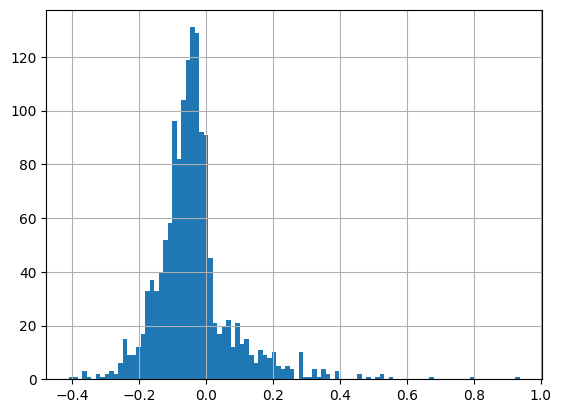

In [6]:
data["logS_over_K"].hist(bins=100)

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader

class OptionDataset(Dataset):
    def __init__(self, df):
        self.strike = torch.tensor(df["K"].values, dtype=torch.float32).view(-1, 1)
        self.tau = torch.tensor(df["tau"].values, dtype=torch.float32).view(-1, 1)
        self.sigma = torch.tensor(df["sigma"].values, dtype=torch.float32).view(-1, 1)
        self.price = torch.tensor(df["logS_over_K"].values, dtype=torch.float32).view(-1, 1)
        self.value = torch.tensor(df["V"].values, dtype=torch.float32).view(-1, 1)
        self.value_scaled = torch.tensor(df["V_scaled"].values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.price)

    def __getitem__(self, idx):
        return {
            "tau": self.tau[idx],
            "sigma": self.sigma[idx],
            "logS_over_K": self.price[idx],
            "V_scaled": self.value_scaled[idx]
        }

train_dataset = OptionDataset(train_df)
val_dataset = OptionDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [9]:
import copy
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm


# =========================================================
# Device
# =========================================================
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


# =========================================================
# Normalizer utilities
# We normalize the 3 physical inputs:
#   x = log(S/K), tau, sigma
# but still differentiate wrt the physical variables.
# =========================================================
@torch.no_grad()
def fit_input_normalizer_from_loader(loader, device):
    feats = []

    for batch in loader:
        x = batch["logS_over_K"].to(device).view(-1, 1).float()
        tau = batch["tau"].to(device).view(-1, 1).float()
        sigma = batch["sigma"].to(device).view(-1, 1).float()

        feats.append(torch.cat([x, tau, sigma], dim=1))

    X = torch.cat(feats, dim=0)
    mean = X.mean(dim=0, keepdim=True)
    std = X.std(dim=0, unbiased=False, keepdim=True).clamp_min(1e-6)
    return mean, std


@torch.no_grad()
def infer_domain_from_loader(loader, device, x_pad=0.10, tau_pad=0.00, sigma_pad=0.00):
    xs, taus, sigmas = [], [], []

    for batch in loader:
        xs.append(batch["logS_over_K"].to(device).view(-1, 1).float())
        taus.append(batch["tau"].to(device).view(-1, 1).float())
        sigmas.append(batch["sigma"].to(device).view(-1, 1).float())

    x_all = torch.cat(xs, dim=0)
    tau_all = torch.cat(taus, dim=0)
    sigma_all = torch.cat(sigmas, dim=0)

    x_min = x_all.min().item()
    x_max = x_all.max().item()
    tau_min = max(0.0, tau_all.min().item())
    tau_max = tau_all.max().item()
    sigma_min = max(1e-4, sigma_all.min().item())
    sigma_max = sigma_all.max().item()

    x_width = max(x_max - x_min, 1e-6)
    tau_width = max(tau_max - tau_min, 1e-6)
    sigma_width = max(sigma_max - sigma_min, 1e-6)

    domain = {
        "x_min": x_min - x_pad * x_width,
        "x_max": x_max + x_pad * x_width,
        "tau_min": max(0.0, tau_min - tau_pad * tau_width),
        "tau_max": tau_max + tau_pad * tau_width,
        "sigma_min": max(1e-4, sigma_min - sigma_pad * sigma_width),
        "sigma_max": sigma_max + sigma_pad * sigma_width,
    }
    return domain


def sample_uniform(n, low, high, device):
    return torch.rand(n, 1, device=device) * (high - low) + low


def sample_collocation_batch(n, domain, device, tau_floor=1e-6):
    x = sample_uniform(n, domain["x_min"], domain["x_max"], device)
    tau_low = max(domain["tau_min"], tau_floor)
    tau = sample_uniform(n, tau_low, domain["tau_max"], device)
    sigma = sample_uniform(n, domain["sigma_min"], domain["sigma_max"], device)
    return x, tau, sigma


def curriculum_domain(full_domain, epoch, curriculum_epochs=75, start_frac=0.35):
    """
    Widens the PDE sampling box over the first curriculum_epochs.
    This is a simple curriculum regularization scheme.
    """
    if curriculum_epochs <= 0:
        return full_domain

    alpha = min(1.0, epoch / float(curriculum_epochs))
    frac = start_frac + (1.0 - start_frac) * alpha

    x_min = min(0.0, full_domain["x_min"] * frac)
    x_max = max(0.0, full_domain["x_max"] * frac)

    tau_min = full_domain["tau_min"]
    tau_max = full_domain["tau_min"] + frac * (full_domain["tau_max"] - full_domain["tau_min"])
    tau_max = max(tau_max, tau_min + 1e-6)

    sigma_min = full_domain["sigma_min"]
    sigma_max = full_domain["sigma_min"] + frac * (full_domain["sigma_max"] - full_domain["sigma_min"])
    sigma_max = max(sigma_max, sigma_min + 1e-6)

    return {
        "x_min": x_min,
        "x_max": x_max,
        "tau_min": tau_min,
        "tau_max": tau_max,
        "sigma_min": sigma_min,
        "sigma_max": sigma_max,
    }


# =========================================================
# Black-Scholes scaled call in transformed variables
# u = C / K
# =========================================================
def norm_cdf(z):
    return 0.5 * (1.0 + torch.erf(z / math.sqrt(2.0)))


def bs_call_scaled_from_x(x, tau, r, sigma):
    """
    Returns u = C / K for a European call.
    x = log(S / K)
    """
    eps = 1e-8
    tau_pos = torch.clamp(tau, min=0.0)
    sigma = torch.clamp(sigma, min=1e-6)

    intrinsic = torch.clamp(torch.expm1(x), min=0.0)

    sqrt_tau = torch.sqrt(tau_pos + eps)
    vol_sqrt_tau = sigma * sqrt_tau + eps

    d1 = (x + (r + 0.5 * sigma**2) * tau_pos) / vol_sqrt_tau
    d2 = d1 - sigma * sqrt_tau

    u_cont = torch.exp(x) * norm_cdf(d1) - torch.exp(-r * tau_pos) * norm_cdf(d2)
    return torch.where(tau_pos < 1e-6, intrinsic, u_cont)


# =========================================================
# Model
# BS anchor + smooth residual correction.
# This fixes the ATM short-maturity scaling mismatch from
# tau * softplus(raw), because ATM time value is O(sigma * sqrt(tau)).
# =========================================================
class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)
        self.act = nn.Tanh()

    def forward(self, x):
        h = self.act(self.fc1(x))
        h = self.act(self.fc2(h))
        return x + h


class PINN(nn.Module):
    def __init__(self, in_dim=3, hidden_dim=128, n_blocks=4, bs_r=0.0):
        super().__init__()
        self.in_dim = in_dim
        self.bs_r = float(bs_r)

        self.input_layer = nn.Linear(in_dim, hidden_dim)
        self.blocks = nn.ModuleList([ResidualBlock(hidden_dim) for _ in range(n_blocks)])
        self.short_head = nn.Linear(hidden_dim, 1)
        self.carry_head = nn.Linear(hidden_dim, 1)
        self.act = nn.Tanh()

        self.register_buffer("feature_mean", torch.zeros(1, in_dim))
        self.register_buffer("feature_std", torch.ones(1, in_dim))

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

        # Start exactly at the BS anchor and let training learn only the residual.
        nn.init.zeros_(self.short_head.weight)
        nn.init.zeros_(self.short_head.bias)
        nn.init.zeros_(self.carry_head.weight)
        nn.init.zeros_(self.carry_head.bias)

    def set_normalizer(self, mean, std):
        self.feature_mean.copy_(mean.detach().clone().view(1, -1))
        self.feature_std.copy_(std.detach().clone().view(1, -1).clamp_min(1e-6))

    def _stack_and_normalize(self, x, tau, sigma):
        feats = torch.cat([x, tau, sigma], dim=1)
        return (feats - self.feature_mean) / self.feature_std

    def forward(self, x, tau=None, sigma=None):
        if tau is None and sigma is None:
            feats_raw = x
            feats = (feats_raw - self.feature_mean) / self.feature_std
            x_phys = feats_raw[:, 0:1]
            tau_phys = feats_raw[:, 1:2]
            sigma_phys = feats_raw[:, 2:3]
        else:
            x_phys = x
            tau_phys = tau
            sigma_phys = sigma
            feats = self._stack_and_normalize(x, tau, sigma)

        h = self.act(self.input_layer(feats))
        for block in self.blocks:
            h = block(h)

        tau_pos = torch.clamp(tau_phys, min=0.0)
        sigma_pos = torch.clamp(sigma_phys, min=1e-6)
        sqrt_tau = torch.sqrt(tau_pos)

        base = bs_call_scaled_from_x(x_phys, tau_pos, self.bs_r, sigma_pos)
        short_residual = sigma_pos * sqrt_tau * torch.tanh(self.short_head(h))
        carry_residual = tau_pos * torch.tanh(self.carry_head(h))

        return base + short_residual + carry_residual


# =========================================================
# Derivatives / PDE residual
# =========================================================
def gradients(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]


def pde_residual(model, x, tau, sigma, r):
    """
    PDE in x = log(S/K), tau, sigma coordinates:

        u_tau - 0.5 sigma^2 u_xx - (r - 0.5 sigma^2) u_x + r u = 0
    """
    x = x.clone().detach().requires_grad_(True)
    tau = tau.clone().detach().requires_grad_(True)
    sigma = sigma.clone().detach()

    u = model(x, tau, sigma)

    u_tau = gradients(u, tau)
    u_x = gradients(u, x)
    u_xx = gradients(u_x, x)

    resid = (
        u_tau
        - 0.5 * sigma**2 * u_xx
        - (r - 0.5 * sigma**2) * u_x
        + r * u
    )
    return resid


# =========================================================
# Losses
# =========================================================
def make_data_importance_weights(
    x,
    tau,
    x_band=0.15,
    tau_focus=0.12,
    atm_boost=2.0,
    short_tau_boost=0.75,
    joint_boost=1.5,
):
    x_band = max(float(x_band), 1e-6)
    tau_focus = max(float(tau_focus), 1e-6)

    tau_pos = torch.clamp(tau, min=0.0)
    atm_score = torch.exp(-torch.square(x / x_band))
    short_tau_score = torch.exp(-tau_pos / tau_focus)

    weights = (
        1.0
        + atm_boost * atm_score
        + short_tau_boost * short_tau_score
        + joint_boost * atm_score * short_tau_score
    )
    return weights / weights.mean().clamp_min(1e-8)


def data_loss(model, x, tau, sigma, v_scaled, weights=None):
    pred = model(x, tau, sigma)
    err2 = (pred - v_scaled) ** 2

    if weights is not None:
        weights = weights / weights.mean().clamp_min(1e-8)
        err2 = err2 * weights

    return err2.mean()


def terminal_loss(model, x, sigma):
    tau0 = torch.zeros_like(x)
    pred = model(x, tau0, sigma)
    target = torch.clamp(torch.expm1(x), min=0.0)
    return torch.mean((pred - target) ** 2)


def boundary_loss(model, tau, sigma, r, x_min, x_max):
    # The domain boundary is finite, so matching BS there is more correct than forcing u=0.
    x_left = torch.full_like(tau, float(x_min))
    x_right = torch.full_like(tau, float(x_max))

    u_left = model(x_left, tau, sigma)
    u_right = model(x_right, tau, sigma)

    target_left = bs_call_scaled_from_x(x_left, tau, r, sigma)
    target_right = bs_call_scaled_from_x(x_right, tau, r, sigma)

    loss_left = torch.mean((u_left - target_left) ** 2)
    loss_right = torch.mean((u_right - target_right) ** 2)
    return loss_left + loss_right


def boundary_loss_(model, tau, sigma, r, x_min, x_max):
    return boundary_loss(model, tau, sigma, r, x_min, x_max)


@torch.no_grad()
def evaluate_data_loss(model, loader, device):
    model.eval()
    running = 0.0
    n_batches = 0

    for batch in loader:
        x = batch["logS_over_K"].to(device).view(-1, 1).float()
        tau = batch["tau"].to(device).view(-1, 1).float()
        sigma = batch["sigma"].to(device).view(-1, 1).float()
        v = batch["V_scaled"].to(device).view(-1, 1).float()

        running += data_loss(model, x, tau, sigma, v).item()
        n_batches += 1

    return running / max(n_batches, 1)


@torch.no_grad()
def predict_scaled(model, x, tau, sigma):
    return model(x, tau, sigma)


@torch.no_grad()
def predict_price(model, x, tau, sigma, K):
    u = model(x, tau, sigma)
    return u * K


In [9]:
def train_european_call_pinn(
    train_loader,
    val_loader,
    r,
    device,
    hidden_dim=128,
    n_blocks=4,
    lr=8e-4,
    weight_decay=1e-5,
    n_epochs=300,
    patience=60,
    lambda_data=8.0,
    lambda_pde=0.5,
    lambda_tc=4.0,
    lambda_bc=0.15,
    n_col=2048,
    n_tc=512,
    n_bc=512,
    pretrain_steps=0,
    pretrain_batch=2048,
    curriculum_epochs=75,
    grad_clip=1.0,
    data_x_band=0.15,
    data_tau_focus=0.12,
    data_atm_boost=2.0,
    data_short_tau_boost=0.75,
    data_joint_boost=1.5,
):
    model = PINN(
        in_dim=3,
        hidden_dim=hidden_dim,
        n_blocks=n_blocks,
        bs_r=r,
    ).to(device)

    feature_mean, feature_std = fit_input_normalizer_from_loader(train_loader, device)
    model.set_normalizer(feature_mean, feature_std)

    full_domain = infer_domain_from_loader(train_loader, device, x_pad=0.10)

    print("Training domain:")
    for k, v in full_domain.items():
        print(f"  {k}: {v:.6f}")

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=n_epochs,
        eta_min=5e-5,
    )

    if pretrain_steps > 0:
        pre_bar = tqdm(range(pretrain_steps), desc="Pretraining (synthetic BS)")
        for step in pre_bar:
            model.train()
            optimizer.zero_grad()

            x_sim, tau_sim, sigma_sim = sample_collocation_batch(
                pretrain_batch, full_domain, device
            )

            u_pred = model(x_sim, tau_sim, sigma_sim)
            u_bs = bs_call_scaled_from_x(x_sim, tau_sim, r, sigma_sim)

            loss_fit = torch.mean((u_pred - u_bs) ** 2)
            resid_sim = pde_residual(model, x_sim, tau_sim, sigma_sim, r)
            loss_pde_sim = torch.mean(resid_sim ** 2)

            loss_pre = loss_fit + 0.05 * loss_pde_sim
            loss_pre.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            if step % 25 == 0:
                pre_bar.set_postfix(
                    pre_fit=f"{loss_fit.item():.6f}",
                    pre_pde=f"{loss_pde_sim.item():.6f}",
                )

    best_val = evaluate_data_loss(model, val_loader, device)
    best_state = copy.deepcopy(model.state_dict())
    no_improve = 0

    print(f"Initial val_loss={best_val:.6f}")

    progress_bar = tqdm(range(n_epochs), desc="Training (market + physics)")

    for epoch in progress_bar:
        current_domain = curriculum_domain(
            full_domain,
            epoch=epoch,
            curriculum_epochs=curriculum_epochs,
            start_frac=0.35,
        )

        model.train()
        running_total = 0.0
        running_data = 0.0
        running_pde = 0.0
        running_tc = 0.0
        running_bc = 0.0
        n_train_batches = 0

        for batch in train_loader:
            x_batch = batch["logS_over_K"].to(device).view(-1, 1).float()
            tau_batch = batch["tau"].to(device).view(-1, 1).float()
            sigma_batch = batch["sigma"].to(device).view(-1, 1).float()
            v_batch = batch["V_scaled"].to(device).view(-1, 1).float()

            optimizer.zero_grad()

            batch_weights = make_data_importance_weights(
                x_batch,
                tau_batch,
                x_band=data_x_band,
                tau_focus=data_tau_focus,
                atm_boost=data_atm_boost,
                short_tau_boost=data_short_tau_boost,
                joint_boost=data_joint_boost,
            )
            loss_data_val = data_loss(
                model=model,
                x=x_batch,
                tau=tau_batch,
                sigma=sigma_batch,
                v_scaled=v_batch,
                weights=batch_weights,
            )

            x_col, tau_col, sigma_col = sample_collocation_batch(
                n=n_col,
                domain=current_domain,
                device=device,
            )
            resid = pde_residual(model, x_col, tau_col, sigma_col, r)
            loss_pde_val = torch.mean(resid ** 2)

            x_tc = sample_uniform(n_tc, current_domain["x_min"], current_domain["x_max"], device)
            sigma_tc = sample_uniform(
                n_tc, current_domain["sigma_min"], current_domain["sigma_max"], device
            )
            loss_tc_val = terminal_loss(model, x_tc, sigma_tc)

            tau_bc = sample_uniform(
                n_bc,
                max(current_domain["tau_min"], 1e-6),
                current_domain["tau_max"],
                device,
            )
            sigma_bc = sample_uniform(
                n_bc, current_domain["sigma_min"], current_domain["sigma_max"], device
            )
            loss_bc_val = boundary_loss(
                model=model,
                tau=tau_bc,
                sigma=sigma_bc,
                r=r,
                x_min=current_domain["x_min"],
                x_max=current_domain["x_max"],
            )

            loss = (
                lambda_data * loss_data_val
                + lambda_pde * loss_pde_val
                + lambda_tc * loss_tc_val
                + lambda_bc * loss_bc_val
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            running_total += loss.item()
            running_data += loss_data_val.item()
            running_pde += loss_pde_val.item()
            running_tc += loss_tc_val.item()
            running_bc += loss_bc_val.item()
            n_train_batches += 1

        avg_train_total = running_total / max(n_train_batches, 1)
        avg_train_data = running_data / max(n_train_batches, 1)
        avg_train_pde = running_pde / max(n_train_batches, 1)
        avg_train_tc = running_tc / max(n_train_batches, 1)
        avg_train_bc = running_bc / max(n_train_batches, 1)

        avg_val = evaluate_data_loss(model, val_loader, device)
        scheduler.step()

        if avg_val < best_val - 1e-7:
            best_val = avg_val
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        progress_bar.set_postfix(
            train=f"{avg_train_total:.6f}",
            data=f"{avg_train_data:.6f}",
            pde=f"{avg_train_pde:.6f}",
            tc=f"{avg_train_tc:.6f}",
            bc=f"{avg_train_bc:.6f}",
            val=f"{avg_val:.6f}",
            lr=f"{scheduler.get_last_lr()[0]:.2e}",
        )

        if epoch % 25 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train={avg_train_total:.6f} | "
                f"data={avg_train_data:.6f} | "
                f"pde={avg_train_pde:.6f} | "
                f"tc={avg_train_tc:.6f} | "
                f"bc={avg_train_bc:.6f} | "
                f"val={avg_val:.6f}"
            )

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}; best val_loss={best_val:.6f}")
            break

    model.load_state_dict(best_state)
    print(f"Loaded best model checkpoint with val_loss={best_val:.6f}")

    return model, {
        "best_val_loss": best_val,
        "domain": full_domain,
        "feature_mean": feature_mean.detach().cpu(),
        "feature_std": feature_std.detach().cpu(),
    }


In [10]:
device = get_device()
r = 0.0364

model, train_info = train_european_call_pinn(
    train_loader=train_loader,
    val_loader=val_loader,
    r=r,
    device=device,
    hidden_dim=256,
    n_blocks=7,
    lr=2e-4,
    weight_decay=1e-5,
    n_epochs=1200,
    patience=120,
    lambda_data=10.0,
    lambda_pde=0.20,
    lambda_tc=1.0,
    lambda_bc=0.10,
    n_col=1024,
    n_tc=256,
    n_bc=256,
    pretrain_steps=0,
    pretrain_batch=1024,
    curriculum_epochs=250,
    grad_clip=1.0,
    data_x_band=0.15,
    data_tau_focus=0.12,
    data_atm_boost=2.0,
    data_short_tau_boost=0.75,
    data_joint_boost=1.5,
)


Training domain:
  x_min: -0.531047
  x_max: 0.913720
  tau_min: 0.019178
  tau_max: 1.764384
  sigma_min: 0.143151
  sigma_max: 1.874299
Initial val_loss=0.000088


Training (market + physics):   0%|          | 1/1200 [00:04<1:25:05,  4.26s/it, bc=0.000045, data=0.000093, lr=2.00e-04, pde=0.000701, tc=0.000000, train=0.001074, val=0.000058]

Epoch    0 | train=0.001074 | data=0.000093 | pde=0.000701 | tc=0.000000 | bc=0.000045 | val=0.000058


Training (market + physics):   2%|▏         | 26/1200 [00:14<07:52,  2.48it/s, bc=0.000061, data=0.000003, lr=2.00e-04, pde=0.000106, tc=0.000000, train=0.000053, val=0.000004] 

Epoch   25 | train=0.000053 | data=0.000003 | pde=0.000106 | tc=0.000000 | bc=0.000061 | val=0.000004


...

Epoch  300 | train=0.000035 | data=0.000002 | pde=0.000070 | tc=0.000000 | bc=0.000026 | val=0.000003


Training (market + physics):  27%|██▋       | 326/1200 [02:16<05:37,  2.59it/s, bc=0.000033, data=0.000002, lr=1.74e-04, pde=0.000078, tc=0.000000, train=0.000034, val=0.000003]

Epoch  325 | train=0.000034 | data=0.000002 | pde=0.000078 | tc=0.000000 | bc=0.000033 | val=0.000003


Training (market + physics):  28%|██▊       | 340/1200 [02:22<06:01,  2.38it/s, bc=0.000025, data=0.000001, lr=1.72e-04, pde=0.000079, tc=0.000000, train=0.000030, val=0.000002]

Early stopping at epoch 340; best val_loss=0.000001
Loaded best model checkpoint with val_loss=0.000001


In [38]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import torch
from torch.distributions.normal import Normal

def black_scholes_price(S, K, tau, r, sigma):
    """
    Black–Scholes European call option price.

    Parameters
    ----------
    S : torch.Tensor
        Spot price
    K : torch.Tensor
        Strike price
    tau : torch.Tensor
        Time to maturity (in years)
    r : float or torch.Tensor
        Risk-free rate
    sigma : torch.Tensor
        Volatility

    Returns
    -------
    torch.Tensor
        Call option price
    """

    eps = 1e-8
    tau = torch.clamp(tau, min=eps)
    sigma = torch.clamp(sigma, min=eps)

    d1 = (torch.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * torch.sqrt(tau))
    d2 = d1 - sigma * torch.sqrt(tau)

    normal = Normal(0.0, 1.0)

    call = S * normal.cdf(d1) - K * torch.exp(-r * tau) * normal.cdf(d2)

    return call


@torch.no_grad()
def compare_pinn_vs_bs(model, df, device, r, price_col="mid_price"):
    out = df.copy()

    # -----------------------------
    # True market price
    # -----------------------------
    if "V_scaled" in out.columns:
        out["C_true"] = out["V_scaled"].astype(float) * out["K"].astype(float)
    elif price_col in out.columns:
        out["C_true"] = out[price_col].astype(float)
    else:
        raise ValueError("Need either V_scaled or a raw price column such as mid_price.")

    # -----------------------------
    # PINN predictions
    # -----------------------------
    x = torch.tensor(out["logS_over_K"].values, dtype=torch.float32, device=device).view(-1, 1)
    tau = torch.tensor(out["tau"].values, dtype=torch.float32, device=device).view(-1, 1)
    sigma = torch.tensor(out["sigma"].values, dtype=torch.float32, device=device).view(-1, 1)
    K = torch.tensor(out["K"].values, dtype=torch.float32, device=device).view(-1, 1)

    u_pinn = predict_scaled(model, x, tau, sigma).detach().cpu().numpy().reshape(-1)
    C_pinn = u_pinn * out["K"].values

    # -----------------------------
    # Pure Black-Scholes predictions
    # -----------------------------
    S = torch.tensor(
        (out["K"].values * np.exp(out["logS_over_K"].values)),
        dtype=torch.float32,
        device=device
    ).view(-1, 1)

    C_bs = black_scholes_price(
        S=S,
        K=K,
        tau=tau,
        r=r,
        sigma=sigma
    ).detach().cpu().numpy().reshape(-1)

    out["C_pinn"] = C_pinn
    out["C_bs"] = C_bs

    # residual above BS
    out["delta_pinn"] = out["C_pinn"] - out["C_bs"]
    out["delta_market"] = out["C_true"] - out["C_bs"]

    # errors
    out["err_pinn"] = out["C_pinn"] - out["C_true"]
    out["err_bs"] = out["C_bs"] - out["C_true"]

    def metrics(pred, true):
        err = pred - true
        mae = np.mean(np.abs(err))
        rmse = np.sqrt(np.mean(err**2))
        return mae, rmse

    pinn_mae, pinn_rmse = metrics(out["C_pinn"].values, out["C_true"].values)
    bs_mae, bs_rmse = metrics(out["C_bs"].values, out["C_true"].values)

    print("Validation comparison")
    print("-" * 40)
    print(f"PINN  MAE : {pinn_mae:.6f}")
    print(f"PINN RMSE : {pinn_rmse:.6f}")
    print(f"BS    MAE : {bs_mae:.6f}")
    print(f"BS   RMSE : {bs_rmse:.6f}")
    print()
    print("Improvement over BS")
    print("-" * 40)
    print(f"MAE  improvement  : {bs_mae - pinn_mae:.6f}")
    print(f"RMSE improvement  : {bs_rmse - pinn_rmse:.6f}")
    print(f"Mean |PINN - BS|   : {np.mean(np.abs(out['delta_pinn'])):.6f}")
    print(f"Mean |Market - BS| : {np.mean(np.abs(out['delta_market'])):.6f}")

    # -----------------------------
    # Plot 1: market residual vs PINN residual relative to BS
    # -----------------------------
    plt.figure(figsize=(6, 6))
    plt.scatter(out["delta_market"], out["delta_pinn"], alpha=0.5, s=16)
    lo = min(out["delta_market"].min(), out["delta_pinn"].min())
    hi = max(out["delta_market"].max(), out["delta_pinn"].max())
    plt.plot([lo, hi], [lo, hi], "--")
    plt.xlabel("Actual residual: Market - BS")
    plt.ylabel("PINN residual: PINN - BS")
    plt.title("Does the PINN learn the correction to BS?")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot 2: absolute errors, PINN vs BS
    # -----------------------------
    plt.figure(figsize=(7, 5))
    plt.scatter(np.abs(out["err_bs"]), np.abs(out["err_pinn"]), alpha=0.5, s=16)
    lo = 0.0
    hi = max(np.abs(out["err_bs"]).max(), np.abs(out["err_pinn"]).max())
    plt.plot([lo, hi], [lo, hi], "--")
    plt.xlabel("|BS - Market|")
    plt.ylabel("|PINN - Market|")
    plt.title("Absolute pricing error: PINN vs Black-Scholes")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return out

In [40]:
tmp = test_df.copy()
tmp["S"] = tmp["K"] * np.exp(tmp["logS_over_K"])

print(tmp[["S", "K", "tau", "sigma", "V", "V_scaled"]].head())

                S       K       tau     sigma       V  V_scaled
877   6632.189941  7200.0  0.441096  0.186064  126.60  0.017583
195   6632.189941  6710.0  0.076712  0.255485  144.50  0.021535
1293  6632.189941  6775.0  0.802740  0.241042  504.70  0.074494
78    6632.189941  6810.0  0.019178  0.260856   21.75  0.003194
231   6632.189941  7030.0  0.076712  0.170945   14.45  0.002055


Validation comparison
----------------------------------------
PINN  MAE : 2.396725
PINN RMSE : 5.949126
BS    MAE : 38.315816
BS   RMSE : 51.978713

Improvement over BS
----------------------------------------
MAE  improvement  : 35.919091
RMSE improvement  : 46.029587
Mean |PINN - BS|   : 38.159602
Mean |Market - BS| : 38.315816


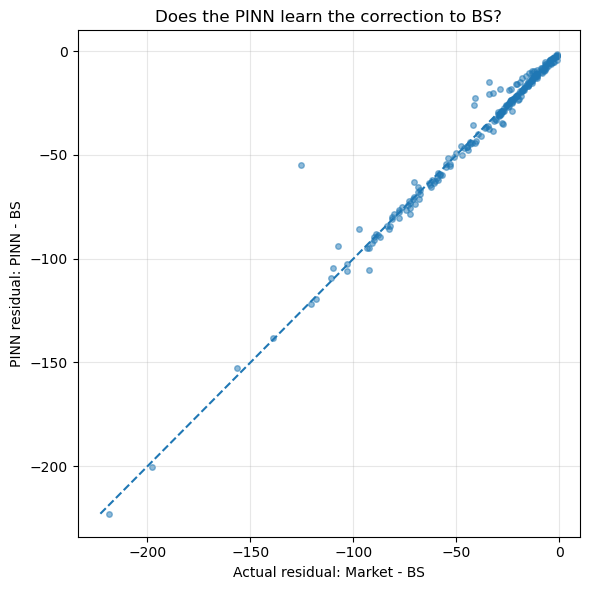

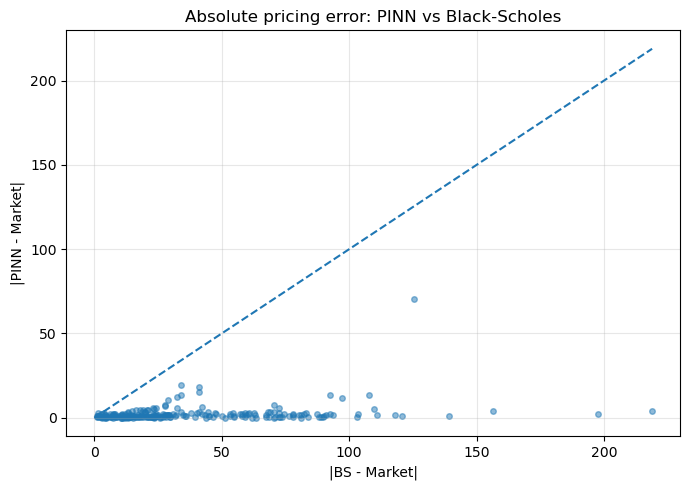

In [39]:
comparison_df = compare_pinn_vs_bs(
    model=model,
    df=test_df,
    device=device,
    r=r,
    price_col="mid_price",   # or whatever your raw market price column is
)

In [41]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torch.distributions.normal import Normal


def black_scholes_price(S, K, tau, r, sigma):
    eps = 1e-8
    tau = torch.clamp(tau, min=eps)
    sigma = torch.clamp(sigma, min=eps)

    d1 = (torch.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * torch.sqrt(tau))
    d2 = d1 - sigma * torch.sqrt(tau)

    normal = Normal(0.0, 1.0)
    call = S * normal.cdf(d1) - K * torch.exp(-r * tau) * normal.cdf(d2)
    return call


def black_scholes_price_q(S, K, tau, r, q, sigma):
    eps = 1e-8
    tau = torch.clamp(tau, min=eps)
    sigma = torch.clamp(sigma, min=eps)

    d1 = (torch.log(S / K) + (r - q + 0.5 * sigma**2) * tau) / (sigma * torch.sqrt(tau))
    d2 = d1 - sigma * torch.sqrt(tau)

    normal = Normal(0.0, 1.0)
    call = torch.exp(-q * tau) * S * normal.cdf(d1) - K * torch.exp(-r * tau) * normal.cdf(d2)
    return call


@torch.no_grad()
def compare_pinn_vs_bs_three_way(
    model,
    df,
    device,
    r,
    q,
    price_col="mid_price",
    use_V_if_present=True,
    make_plots=True,
):
    """
    Compare:
      1) PINN
      2) Black-Scholes with q = 0
      3) Black-Scholes with dividend yield q

    Parameters
    ----------
    model : torch.nn.Module
        Trained PINN model
    df : pd.DataFrame
        DataFrame with at least:
        ['logS_over_K', 'tau', 'sigma', 'K'] and either ['V'] / ['V_scaled'] / [price_col]
    device : torch.device
    r : float
        Risk-free rate
    q : float
        Continuous dividend yield for dividend-adjusted BS
    price_col : str
        Raw price column fallback, e.g. 'mid_price'
    use_V_if_present : bool
        If True, prefer df['V'] as the true option price target if available
    make_plots : bool
        Whether to generate plots

    Returns
    -------
    out : pd.DataFrame
        DataFrame with predictions, residuals, and errors
    """

    out = df.copy()

    # -------------------------------------------------
    # Choose the true market price column carefully
    # -------------------------------------------------
    if use_V_if_present and ("V" in out.columns):
        out["C_true"] = out["V"].astype(float)
        true_label = "V"
    elif "V_scaled" in out.columns:
        out["C_true"] = out["V_scaled"].astype(float) * out["K"].astype(float)
        true_label = "V_scaled * K"
    elif price_col in out.columns:
        out["C_true"] = out[price_col].astype(float)
        true_label = price_col
    else:
        raise ValueError("Need one of: 'V', 'V_scaled', or a raw price column such as 'mid_price'.")

    # -------------------------------------------------
    # Build tensors
    # -------------------------------------------------
    x = torch.tensor(out["logS_over_K"].values, dtype=torch.float32, device=device).view(-1, 1)
    tau = torch.tensor(out["tau"].values, dtype=torch.float32, device=device).view(-1, 1)
    sigma = torch.tensor(out["sigma"].values, dtype=torch.float32, device=device).view(-1, 1)
    K = torch.tensor(out["K"].values, dtype=torch.float32, device=device).view(-1, 1)

    S_np = out["K"].values * np.exp(out["logS_over_K"].values)
    S = torch.tensor(S_np, dtype=torch.float32, device=device).view(-1, 1)

    # -------------------------------------------------
    # PINN predictions
    # -------------------------------------------------
    u_pinn = predict_scaled(model, x, tau, sigma).detach().cpu().numpy().reshape(-1)
    C_pinn = u_pinn * out["K"].values

    # -------------------------------------------------
    # BS predictions
    # -------------------------------------------------
    C_bs_q0 = black_scholes_price(
        S=S, K=K, tau=tau, r=r, sigma=sigma
    ).detach().cpu().numpy().reshape(-1)

    C_bs_q = black_scholes_price_q(
        S=S, K=K, tau=tau, r=r, q=q, sigma=sigma
    ).detach().cpu().numpy().reshape(-1)

    # -------------------------------------------------
    # Store outputs
    # -------------------------------------------------
    out["S"] = S_np
    out["C_pinn"] = C_pinn
    out["C_bs_q0"] = C_bs_q0
    out["C_bs_q"] = C_bs_q

    # residuals relative to BS(q=0)
    out["delta_market_vs_bs_q0"] = out["C_true"] - out["C_bs_q0"]
    out["delta_pinn_vs_bs_q0"] = out["C_pinn"] - out["C_bs_q0"]

    # residuals relative to BS(q)
    out["delta_market_vs_bs_q"] = out["C_true"] - out["C_bs_q"]
    out["delta_pinn_vs_bs_q"] = out["C_pinn"] - out["C_bs_q"]

    # errors
    out["err_pinn"] = out["C_pinn"] - out["C_true"]
    out["err_bs_q0"] = out["C_bs_q0"] - out["C_true"]
    out["err_bs_q"] = out["C_bs_q"] - out["C_true"]

    def metrics(pred, true):
        err = pred - true
        mae = np.mean(np.abs(err))
        rmse = np.sqrt(np.mean(err**2))
        return mae, rmse

    pinn_mae, pinn_rmse = metrics(out["C_pinn"].values, out["C_true"].values)
    bs0_mae, bs0_rmse = metrics(out["C_bs_q0"].values, out["C_true"].values)
    bsq_mae, bsq_rmse = metrics(out["C_bs_q"].values, out["C_true"].values)

    print("Validation comparison")
    print("-" * 60)
    print(f"True price source : {true_label}")
    print(f"r                 : {r}")
    print(f"q                 : {q}")
    print("-" * 60)
    print(f"PINN        MAE   : {pinn_mae:.6f}")
    print(f"PINN        RMSE  : {pinn_rmse:.6f}")
    print(f"BS (q=0)    MAE   : {bs0_mae:.6f}")
    print(f"BS (q=0)    RMSE  : {bs0_rmse:.6f}")
    print(f"BS (q={q})  MAE   : {bsq_mae:.6f}")
    print(f"BS (q={q})  RMSE  : {bsq_rmse:.6f}")
    print()
    print("Improvement over Black-Scholes")
    print("-" * 60)
    print(f"PINN vs BS(q=0)  MAE improvement  : {bs0_mae - pinn_mae:.6f}")
    print(f"PINN vs BS(q=0)  RMSE improvement : {bs0_rmse - pinn_rmse:.6f}")
    print(f"PINN vs BS(q)    MAE improvement  : {bsq_mae - pinn_mae:.6f}")
    print(f"PINN vs BS(q)    RMSE improvement : {bsq_rmse - pinn_rmse:.6f}")
    print()
    print("Mean absolute deviations")
    print("-" * 60)
    print(f"Mean |PINN - BS(q=0)|   : {np.mean(np.abs(out['C_pinn'] - out['C_bs_q0'])):.6f}")
    print(f"Mean |PINN - BS(q)|     : {np.mean(np.abs(out['C_pinn'] - out['C_bs_q'])):.6f}")
    print(f"Mean |Market - BS(q=0)| : {np.mean(np.abs(out['C_true'] - out['C_bs_q0'])):.6f}")
    print(f"Mean |Market - BS(q)|   : {np.mean(np.abs(out['C_true'] - out['C_bs_q'])):.6f}")

    if make_plots:
        # -------------------------------------------------
        # Plot 1: absolute error comparison for q=0 BS
        # -------------------------------------------------
        plt.figure(figsize=(7, 5))
        plt.scatter(np.abs(out["err_bs_q0"]), np.abs(out["err_pinn"]), alpha=0.5, s=16)
        lo = 0.0
        hi = max(np.abs(out["err_bs_q0"]).max(), np.abs(out["err_pinn"]).max())
        plt.plot([lo, hi], [lo, hi], "--")
        plt.xlabel("|BS(q=0) - Market|")
        plt.ylabel("|PINN - Market|")
        plt.title("Absolute pricing error: PINN vs BS(q=0)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # -------------------------------------------------
        # Plot 2: absolute error comparison for dividend-adjusted BS
        # -------------------------------------------------
        plt.figure(figsize=(7, 5))
        plt.scatter(np.abs(out["err_bs_q"]), np.abs(out["err_pinn"]), alpha=0.5, s=16)
        lo = 0.0
        hi = max(np.abs(out["err_bs_q"]).max(), np.abs(out["err_pinn"]).max())
        plt.plot([lo, hi], [lo, hi], "--")
        plt.xlabel(f"|BS(q={q}) - Market|")
        plt.ylabel("|PINN - Market|")
        plt.title(f"Absolute pricing error: PINN vs BS(q={q})")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # -------------------------------------------------
        # Plot 3: residual-learning check relative to BS(q=0)
        # -------------------------------------------------
        plt.figure(figsize=(6, 6))
        plt.scatter(out["delta_market_vs_bs_q0"], out["delta_pinn_vs_bs_q0"], alpha=0.5, s=16)
        lo = min(out["delta_market_vs_bs_q0"].min(), out["delta_pinn_vs_bs_q0"].min())
        hi = max(out["delta_market_vs_bs_q0"].max(), out["delta_pinn_vs_bs_q0"].max())
        plt.plot([lo, hi], [lo, hi], "--")
        plt.xlabel("Actual residual: Market - BS(q=0)")
        plt.ylabel("PINN residual: PINN - BS(q=0)")
        plt.title("Does the PINN learn the correction to BS(q=0)?")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        # -------------------------------------------------
        # Plot 4: residual-learning check relative to BS(q)
        # -------------------------------------------------
        plt.figure(figsize=(6, 6))
        plt.scatter(out["delta_market_vs_bs_q"], out["delta_pinn_vs_bs_q"], alpha=0.5, s=16)
        lo = min(out["delta_market_vs_bs_q"].min(), out["delta_pinn_vs_bs_q"].min())
        hi = max(out["delta_market_vs_bs_q"].max(), out["delta_pinn_vs_bs_q"].max())
        plt.plot([lo, hi], [lo, hi], "--")
        plt.xlabel(f"Actual residual: Market - BS(q={q})")
        plt.ylabel(f"PINN residual: PINN - BS(q={q})")
        plt.title(f"Does the PINN learn the correction to BS(q={q})?")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return out

Validation comparison
------------------------------------------------------------
True price source : V
r                 : 0.0364
q                 : 0.015
------------------------------------------------------------
PINN        MAE   : 2.396725
PINN        RMSE  : 5.949126
BS (q=0)    MAE   : 38.315816
BS (q=0)    RMSE  : 51.978713
BS (q=0.015)  MAE   : 21.341188
BS (q=0.015)  RMSE  : 26.477739

Improvement over Black-Scholes
------------------------------------------------------------
PINN vs BS(q=0)  MAE improvement  : 35.919091
PINN vs BS(q=0)  RMSE improvement : 46.029587
PINN vs BS(q)    MAE improvement  : 18.944462
PINN vs BS(q)    RMSE improvement : 20.528613

Mean absolute deviations
------------------------------------------------------------
Mean |PINN - BS(q=0)|   : 38.159602
Mean |PINN - BS(q)|     : 21.324246
Mean |Market - BS(q=0)| : 38.315816
Mean |Market - BS(q)|   : 21.341188


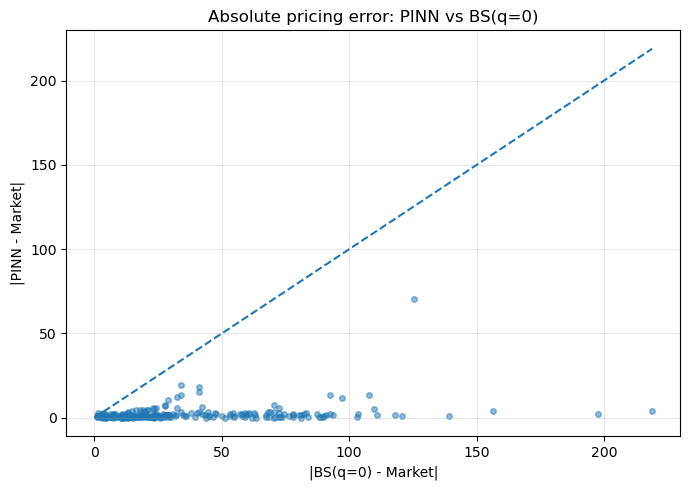

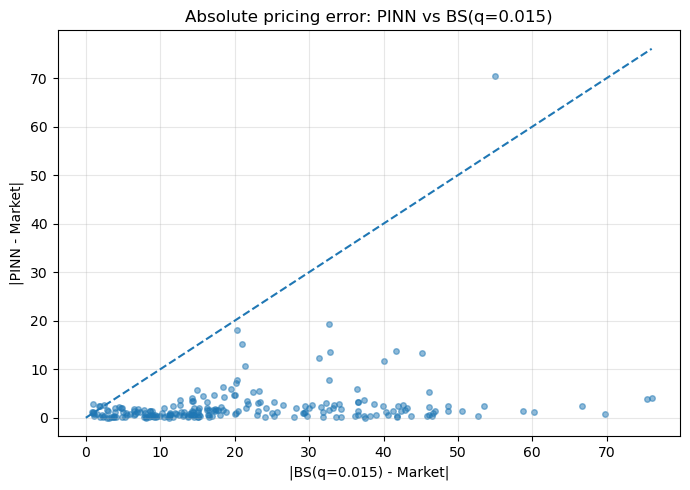

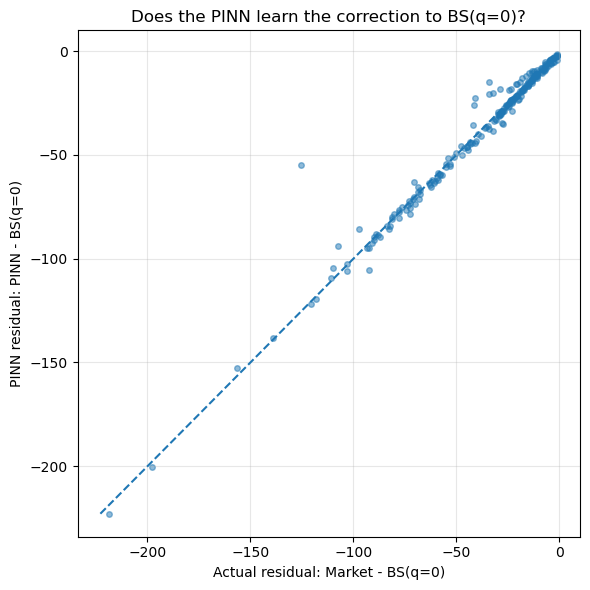

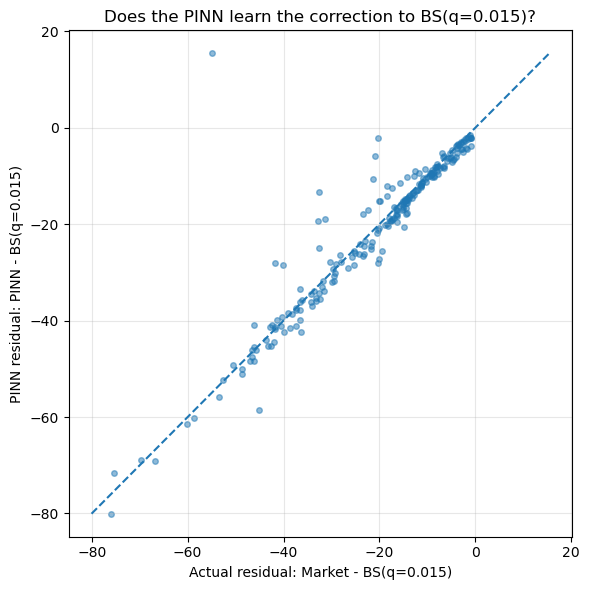

In [42]:
comparison_df = compare_pinn_vs_bs_three_way(
    model=model,
    df=test_df,
    device=device,
    r=r,
    q=0.015,          # example dividend yield
    price_col="mid_price",
    use_V_if_present=True,
    make_plots=True,
)

In [44]:
for q in [0.0, 0.01, 0.015, 0.02, 0.03, 0.035, 0.04]:
    print("\n", "=" * 80)
    print(f"Testing q = {q}")
    _ = compare_pinn_vs_bs_three_way(
        model=model,
        df=val_df,
        device=device,
        r=r,
        q=q,
        price_col="mid_price",
        use_V_if_present=True,
        make_plots=False,
    )


Testing q = 0.0
Validation comparison
------------------------------------------------------------
True price source : V
r                 : 0.0364
q                 : 0.0
------------------------------------------------------------
PINN        MAE   : 2.181950
PINN        RMSE  : 4.950973
BS (q=0)    MAE   : 41.152369
BS (q=0)    RMSE  : 57.187868
BS (q=0.0)  MAE   : 41.152369
BS (q=0.0)  RMSE  : 57.187868

Improvement over Black-Scholes
------------------------------------------------------------
PINN vs BS(q=0)  MAE improvement  : 38.970418
PINN vs BS(q=0)  RMSE improvement : 52.236895
PINN vs BS(q)    MAE improvement  : 38.970418
PINN vs BS(q)    RMSE improvement : 52.236895

Mean absolute deviations
------------------------------------------------------------
Mean |PINN - BS(q=0)|   : 41.053930
Mean |PINN - BS(q)|     : 41.053930
Mean |Market - BS(q=0)| : 41.152369
Mean |Market - BS(q)|   : 41.152369

Testing q = 0.01
Validation comparison
----------------------------------------

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def diagnostic_plots_pinn_vs_bs(
    comparison_df,
    bs_col="C_bs_q",
    pinn_col="C_pinn",
    true_col="C_true",
    moneyness_col="logS_over_K",
    tau_col="tau",
    n_bins=20,
):
    """
    Plot where PINN improves over Black-Scholes.

    Parameters
    ----------
    comparison_df : pd.DataFrame
        Output from compare_pinn_vs_bs_three_way(...)
    bs_col : str
        Column for BS predictions. Use "C_bs_q" for dividend-adjusted BS,
        or "C_bs_q0" for q=0 BS.
    pinn_col : str
        Column for PINN predictions
    true_col : str
        Column for true market price
    moneyness_col : str
        Column for log(S/K)
    tau_col : str
        Column for time to maturity
    n_bins : int
        Number of quantile bins for the summary curves
    """

    df = comparison_df.copy()

    # pointwise absolute errors
    df["abs_err_bs"] = np.abs(df[bs_col] - df[true_col])
    df["abs_err_pinn"] = np.abs(df[pinn_col] - df[true_col])

    # positive means PINN is better
    df["improvement"] = df["abs_err_bs"] - df["abs_err_pinn"]

    # -----------------------------
    # Helper: quantile-binned summary
    # -----------------------------
    def make_binned_summary(xcol):
        tmp = df[[xcol, "abs_err_bs", "abs_err_pinn", "improvement"]].dropna().copy()

        # handle duplicates in qcut
        tmp["bin"] = pd.qcut(tmp[xcol], q=n_bins, duplicates="drop")

        summary = (
            tmp.groupby("bin", observed=False)
            .agg(
                x_mid=(xcol, "mean"),
                bs_mae=("abs_err_bs", "mean"),
                pinn_mae=("abs_err_pinn", "mean"),
                improvement_mean=("improvement", "mean"),
                count=(xcol, "size"),
            )
            .reset_index(drop=True)
        )
        return summary

    summary_m = make_binned_summary(moneyness_col)
    summary_t = make_binned_summary(tau_col)

    # -----------------------------
    # Plot 1: error vs moneyness
    # -----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(summary_m["x_mid"], summary_m["bs_mae"], marker="o", label="BS abs error")
    plt.plot(summary_m["x_mid"], summary_m["pinn_mae"], marker="o", label="PINN abs error")
    plt.xlabel("Moneyness: log(S/K)")
    plt.ylabel("Mean absolute pricing error")
    plt.title("Pricing error vs moneyness")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot 2: improvement vs moneyness
    # -----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(summary_m["x_mid"], summary_m["improvement_mean"], marker="o")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Moneyness: log(S/K)")
    plt.ylabel("Mean improvement = |BS error| - |PINN error|")
    plt.title("Where PINN improves over BS across moneyness")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot 3: error vs maturity
    # -----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(summary_t["x_mid"], summary_t["bs_mae"], marker="o", label="BS abs error")
    plt.plot(summary_t["x_mid"], summary_t["pinn_mae"], marker="o", label="PINN abs error")
    plt.xlabel("Time to maturity: tau")
    plt.ylabel("Mean absolute pricing error")
    plt.title("Pricing error vs time to maturity")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Plot 4: improvement vs maturity
    # -----------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(summary_t["x_mid"], summary_t["improvement_mean"], marker="o")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Time to maturity: tau")
    plt.ylabel("Mean improvement = |BS error| - |PINN error|")
    plt.title("Where PINN improves over BS across maturity")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return summary_m, summary_t

In [47]:
comparison_df = compare_pinn_vs_bs_three_way(
    model=model,
    df=test_df,
    device=device,
    r=r,
    q=0.03,              # use the q that looked most reasonable
    price_col="mid_price",
    use_V_if_present=True,
    make_plots=False,
)

Validation comparison
------------------------------------------------------------
True price source : V
r                 : 0.0364
q                 : 0.03
------------------------------------------------------------
PINN        MAE   : 2.396725
PINN        RMSE  : 5.949126
BS (q=0)    MAE   : 38.315816
BS (q=0)    RMSE  : 51.978713
BS (q=0.03)  MAE   : 7.135322
BS (q=0.03)  RMSE  : 9.976656

Improvement over Black-Scholes
------------------------------------------------------------
PINN vs BS(q=0)  MAE improvement  : 35.919091
PINN vs BS(q=0)  RMSE improvement : 46.029587
PINN vs BS(q)    MAE improvement  : 4.738597
PINN vs BS(q)    RMSE improvement : 4.027531

Mean absolute deviations
------------------------------------------------------------
Mean |PINN - BS(q=0)|   : 38.159602
Mean |PINN - BS(q)|     : 8.297525
Mean |Market - BS(q=0)| : 38.315816
Mean |Market - BS(q)|   : 7.135322


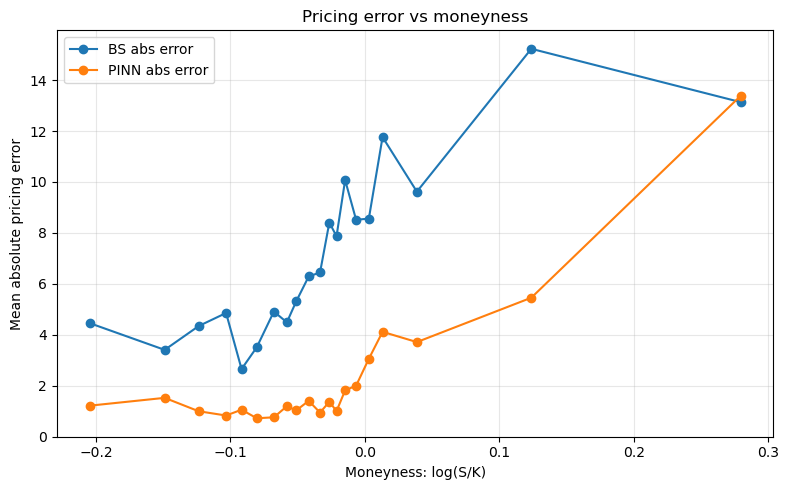

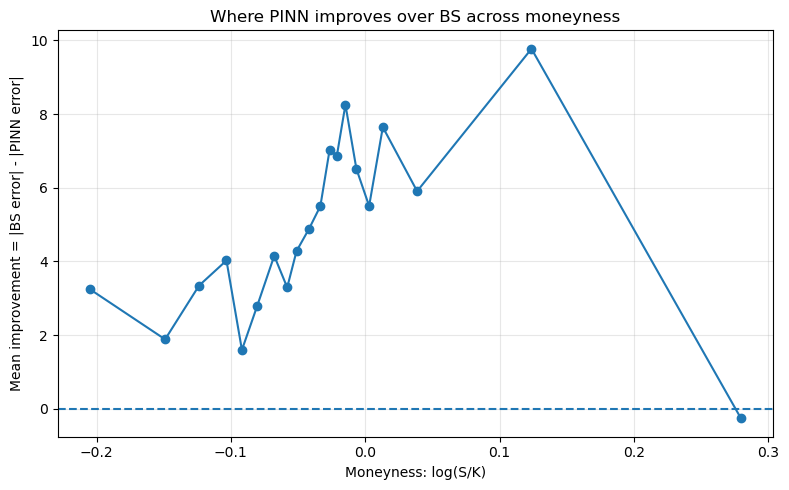

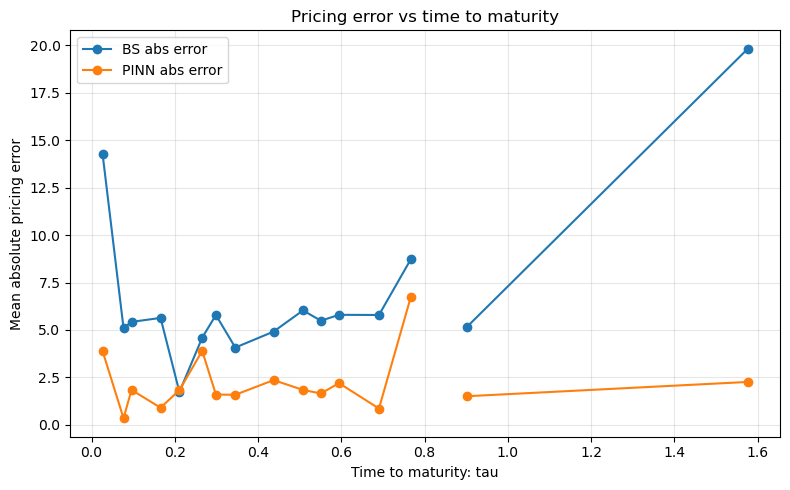

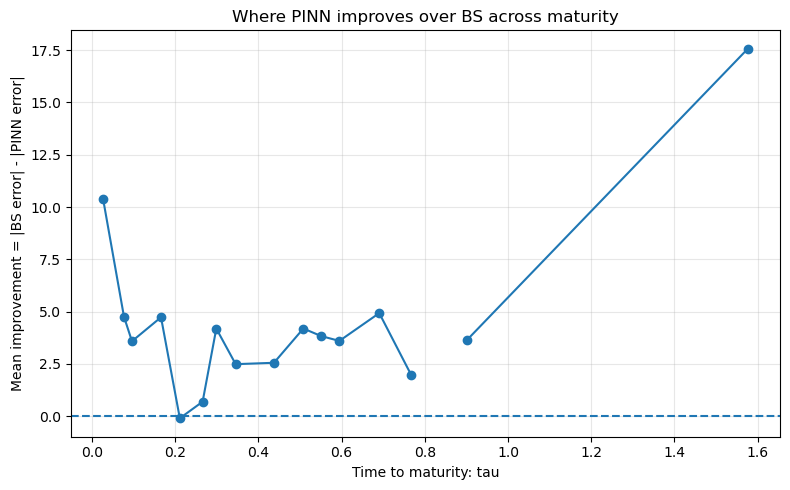

In [48]:
summary_m, summary_t = diagnostic_plots_pinn_vs_bs(
    comparison_df,
    bs_col="C_bs_q",     # dividend-adjusted BS
    pinn_col="C_pinn",
    true_col="C_true",
    moneyness_col="logS_over_K",
    tau_col="tau",
    n_bins=20,
)

In [11]:
full_domain = train_info["domain"]
full_domain


{'x_min': -0.531047323346138,
 'x_max': 0.9137200206518173,
 'tau_min': 0.019178081303834915,
 'tau_max': 1.7643835544586182,
 'sigma_min': 0.14315126836299896,
 'sigma_max': 1.8742986917495728}

In [12]:
import torch
import torch.nn as nn

class BSWrapper(nn.Module):
    def __init__(self, r):
        super().__init__()
        self.r = r

    def forward(self, x, tau, sigma):
        return bs_call_scaled_from_x(x, tau, self.r, sigma)

def debug_bs_residual(device, r, domain, n=5000):
    bs_model = BSWrapper(r).to(device)

    x, tau, sigma = sample_collocation_batch(n, domain, device)

    # need grads for PDE residual
    x.requires_grad_(True)
    tau.requires_grad_(True)
    sigma.requires_grad_(True)

    resid = pde_residual(bs_model, x, tau, sigma, r)

    print("BS residual mean abs :", resid.abs().mean().item())
    print("BS residual max abs  :", resid.abs().max().item())
    print("BS residual rmse     :", torch.sqrt(torch.mean(resid**2)).item())

In [13]:
def debug_bs_conditions(device, r, domain, n=5000):
    bs_model = BSWrapper(r).to(device)

    x_tc = sample_uniform(n, domain["x_min"], domain["x_max"], device)
    sigma_tc = sample_uniform(n, domain["sigma_min"], domain["sigma_max"], device)
    tc = terminal_loss(bs_model, x_tc, sigma_tc)

    tau_bc = sample_uniform(n, max(domain["tau_min"], 1e-6), domain["tau_max"], device)
    sigma_bc = sample_uniform(n, domain["sigma_min"], domain["sigma_max"], device)
    bc = boundary_loss(
        model=bs_model,
        tau=tau_bc,
        sigma=sigma_bc,
        r=r,
        x_min=domain["x_min"],
        x_max=domain["x_max"],
    )

    print("BS terminal loss:", tc.item())
    print("BS boundary loss:", bc.item())

In [14]:
debug_bs_residual(
    device=device,
    r=r,
    domain=full_domain,
    n=5000,
)

BS residual mean abs : 5.7556182042617365e-08
BS residual max abs  : 1.2740492820739746e-06
BS residual rmse     : 9.953615176527819e-08


In [15]:
debug_bs_conditions(
    device=device,
    r=r,
    domain=full_domain,
    n=5000,
)

BS terminal loss: 0.0
BS boundary loss: 0.0


In [374]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader


def build_stage3_sample_weights(
    df,
    x_col="logS_over_K",
    tau_col="tau",
    x_band=0.12,
    tau_focus=0.12,
    atm_boost=2.0,
    tau_boost=1.0,
    joint_boost=1.5,
):
    """
    Returns one weight per row for diagnostics.

    Stage 3 should emphasize ATM and shorter maturities, but not via
    aggressive oversampling. Oversampling changed the data distribution
    too much and often degraded a good stage-2 model.
    """
    x = df[x_col].to_numpy(dtype=float)
    tau = np.clip(df[tau_col].to_numpy(dtype=float), 0.0, None)

    atm_score = np.exp(-np.square(x / max(x_band, 1e-6)))
    short_tau_score = np.exp(-tau / max(tau_focus, 1e-6))

    w = (
        1.0
        + atm_boost * atm_score
        + tau_boost * short_tau_score
        + joint_boost * atm_score * short_tau_score
    )

    if "spread_pct" in df.columns:
        spread = df["spread_pct"].to_numpy(dtype=float)
        spread = np.nan_to_num(spread, nan=np.nanmedian(spread))
        liq_mult = 1.0 / (1.0 + 5.0 * np.clip(spread, 0.0, 1.0))
        w *= liq_mult

    if "openInterest" in df.columns:
        oi = np.nan_to_num(df["openInterest"].to_numpy(dtype=float), nan=0.0)
        oi_mult = 1.0 + 0.25 * np.log1p(np.clip(oi, 0.0, None))
        oi_mult /= np.mean(oi_mult)
        w *= oi_mult

    w = np.clip(w, 1e-6, None)
    w = w / np.mean(w)
    return w.astype(np.float64)


In [285]:
def make_stage3_train_loader(
    train_dataset,
    train_df,
    batch_size,
    x_band=0.12,
    tau_focus=0.12,
    atm_boost=2.0,
    tau_boost=1.0,
    joint_boost=1.5,
    num_workers=0,
):
    weights = build_stage3_sample_weights(
        train_df,
        x_band=x_band,
        tau_focus=tau_focus,
        atm_boost=atm_boost,
        tau_boost=tau_boost,
        joint_boost=joint_boost,
    )

    loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=False,
    )
    return loader, weights


In [358]:
def sample_collocation_batch_stage3(
    n,
    domain,
    device,
    focus_frac=0.25,
    x_focus=0.12,
    tau_focus=0.12,
):
    n_focus = int(n * focus_frac)
    n_uniform = n - n_focus

    x_u = sample_uniform(n_uniform, domain["x_min"], domain["x_max"], device)
    tau_u = sample_uniform(n_uniform, max(domain["tau_min"], 1e-6), domain["tau_max"], device)
    sigma_u = sample_uniform(n_uniform, domain["sigma_min"], domain["sigma_max"], device)

    tau_low = max(domain["tau_min"], 1e-6)
    tau_high = min(domain["tau_max"], max(tau_low + 1e-6, tau_focus))
    x_low = max(domain["x_min"], -x_focus)
    x_high = min(domain["x_max"], x_focus)

    if n_focus <= 0 or x_low >= x_high or tau_low >= tau_high:
        return x_u, tau_u, sigma_u

    x_f = sample_uniform(n_focus, x_low, x_high, device)
    tau_f = sample_uniform(n_focus, tau_low, tau_high, device)
    sigma_f = sample_uniform(n_focus, domain["sigma_min"], domain["sigma_max"], device)

    x = torch.cat([x_u, x_f], dim=0)
    tau = torch.cat([tau_u, tau_f], dim=0)
    sigma = torch.cat([sigma_u, sigma_f], dim=0)

    perm = torch.randperm(n, device=device)
    return x[perm], tau[perm], sigma[perm]


In [359]:
def make_focus_mask(df, x_band=0.12, tau_focus=0.12):
    return (df["logS_over_K"].abs() <= x_band) & (df["tau"] <= tau_focus)


In [361]:
import copy
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm


def subset_from_mask(dataset, mask):
    indices = np.where(mask.to_numpy())[0].tolist()
    return Subset(dataset, indices), indices


def set_stage3_trainable_params(model, train_backbone=False):
    for param in model.parameters():
        param.requires_grad = train_backbone

    for module_name in ("short_head", "carry_head", "output_layer"):
        module = getattr(model, module_name, None)
        if module is not None:
            for param in module.parameters():
                param.requires_grad = True


def fine_tune_stage3(
    model,
    train_dataset,
    train_df,
    val_dataset,
    val_df,
    device,
    r,
    batch_size=64,
    lr=3e-5,
    weight_decay=1e-6,
    n_epochs=300,
    patience=80,
    lambda_data=12.0,
    lambda_pde=0.10,
    lambda_tc=0.5,
    lambda_bc=0.05,
    n_col=1024,
    n_tc=256,
    n_bc=256,
    x_band=0.12,
    tau_focus=0.12,
    atm_boost=2.0,
    tau_boost=1.0,
    joint_boost=1.5,
    focus_frac=0.25,
    grad_clip=1.0,
    train_backbone=False,
):
    stage3_train_loader, _ = make_stage3_train_loader(
        train_dataset=train_dataset,
        train_df=train_df,
        batch_size=batch_size,
        x_band=x_band,
        tau_focus=tau_focus,
        atm_boost=atm_boost,
        tau_boost=tau_boost,
        joint_boost=joint_boost,
    )

    val_loader_full = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    val_focus_mask = make_focus_mask(val_df, x_band=x_band, tau_focus=tau_focus)
    val_focus_dataset, _ = subset_from_mask(val_dataset, val_focus_mask)
    val_loader_focus = DataLoader(val_focus_dataset, batch_size=batch_size, shuffle=False)

    base_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    full_domain = infer_domain_from_loader(base_train_loader, device, x_pad=0.05)

    set_stage3_trainable_params(model, train_backbone=train_backbone)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=n_epochs, eta_min=1e-5
    )

    val_full = evaluate_data_loss(model, val_loader_full, device)
    val_focus = (
        evaluate_data_loss(model, val_loader_focus, device)
        if len(val_focus_dataset) > 0
        else val_full
    )
    best_metric = 0.5 * val_full + 0.5 * val_focus
    best_state = copy.deepcopy(model.state_dict())
    no_improve = 0

    print(
        f"Initial stage-3 metric={best_metric:.6f} "
        f"| val_full={val_full:.6f} | val_focus={val_focus:.6f}"
    )

    bar = tqdm(range(n_epochs), desc="Stage 3 fine-tune")

    for epoch in bar:
        model.train()
        run_total = 0.0
        run_data = 0.0
        run_pde = 0.0
        run_tc = 0.0
        run_bc = 0.0
        n_batches = 0

        for batch in stage3_train_loader:
            x_batch = batch["logS_over_K"].to(device).view(-1, 1).float()
            tau_batch = batch["tau"].to(device).view(-1, 1).float()
            sigma_batch = batch["sigma"].to(device).view(-1, 1).float()
            v_batch = batch["V_scaled"].to(device).view(-1, 1).float()

            optimizer.zero_grad()

            batch_weights = make_data_importance_weights(
                x_batch,
                tau_batch,
                x_band=x_band,
                tau_focus=tau_focus,
                atm_boost=atm_boost,
                short_tau_boost=tau_boost,
                joint_boost=joint_boost,
            )
            loss_data_val = data_loss(
                model,
                x_batch,
                tau_batch,
                sigma_batch,
                v_batch,
                weights=batch_weights,
            )

            x_col, tau_col, sigma_col = sample_collocation_batch_stage3(
                n=n_col,
                domain=full_domain,
                device=device,
                focus_frac=focus_frac,
                x_focus=x_band,
                tau_focus=tau_focus,
            )
            resid = pde_residual(model, x_col, tau_col, sigma_col, r)
            loss_pde_val = torch.mean(resid ** 2)

            x_tc = sample_uniform(n_tc, full_domain["x_min"], full_domain["x_max"], device)
            sigma_tc = sample_uniform(n_tc, full_domain["sigma_min"], full_domain["sigma_max"], device)
            loss_tc_val = terminal_loss(model, x_tc, sigma_tc)

            tau_bc = sample_uniform(
                n_bc, max(full_domain["tau_min"], 1e-6), full_domain["tau_max"], device
            )
            sigma_bc = sample_uniform(
                n_bc, full_domain["sigma_min"], full_domain["sigma_max"], device
            )
            loss_bc_val = boundary_loss(
                model=model,
                tau=tau_bc,
                sigma=sigma_bc,
                r=r,
                x_min=full_domain["x_min"],
                x_max=full_domain["x_max"],
            )

            loss = (
                lambda_data * loss_data_val
                + lambda_pde * loss_pde_val
                + lambda_tc * loss_tc_val
                + lambda_bc * loss_bc_val
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(params, grad_clip)
            optimizer.step()

            run_total += loss.item()
            run_data += loss_data_val.item()
            run_pde += loss_pde_val.item()
            run_tc += loss_tc_val.item()
            run_bc += loss_bc_val.item()
            n_batches += 1

        avg_train = run_total / max(n_batches, 1)
        avg_data = run_data / max(n_batches, 1)
        avg_pde = run_pde / max(n_batches, 1)
        avg_tc = run_tc / max(n_batches, 1)
        avg_bc = run_bc / max(n_batches, 1)

        val_full = evaluate_data_loss(model, val_loader_full, device)
        val_focus = (
            evaluate_data_loss(model, val_loader_focus, device)
            if len(val_focus_dataset) > 0
            else val_full
        )
        val_metric = 0.5 * val_full + 0.5 * val_focus

        scheduler.step()

        if val_metric < best_metric - 1e-7:
            best_metric = val_metric
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        bar.set_postfix(
            train=f"{avg_train:.6f}",
            data=f"{avg_data:.6f}",
            pde=f"{avg_pde:.6f}",
            tc=f"{avg_tc:.6f}",
            bc=f"{avg_bc:.6f}",
            val_full=f"{val_full:.6f}",
            val_focus=f"{val_focus:.6f}",
            metric=f"{val_metric:.6f}",
            lr=f"{scheduler.get_last_lr()[0]:.2e}",
        )

        if epoch % 25 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train={avg_train:.6f} | "
                f"val_full={val_full:.6f} | "
                f"val_focus={val_focus:.6f} | "
                f"metric={val_metric:.6f}"
            )

        if no_improve >= patience:
            print(f"Stage 3 early stopping at epoch {epoch}; best_metric={best_metric:.6f}")
            break

    model.load_state_dict(best_state)
    print(f"Loaded best stage-3 checkpoint with metric={best_metric:.6f}")

    return model


## Dont run this cell its for fine tuning

In [362]:
stage3_model = fine_tune_stage3(
    model=copy.deepcopy(model),
    train_dataset=train_dataset,
    train_df=train_df,
    val_dataset=val_dataset,
    val_df=val_df,
    device=device,
    r=r,
    batch_size=128,
    lr=5e-6,
    weight_decay=1e-6,
    n_epochs=150,
    patience=40,
    lambda_data=12.0,
    lambda_pde=0.10,
    lambda_tc=0.5,
    lambda_bc=0.05,
    n_col=1024,
    n_tc=256,
    n_bc=256,
    x_band=0.12,
    tau_focus=0.12,
    atm_boost=2.0,
    tau_boost=1.0,
    joint_boost=1.5,
    focus_frac=0.15,
    grad_clip=1.0,
    train_backbone=False,
)


Stage 3 fine-tune:   0%|          | 1/300 [00:04<20:45,  4.17s/it, bc=0.000045, data=0.000020, lr=1.00e-05, metric=0.000077, pde=0.001270, tc=0.000000, train=0.000513, val_focus=0.000061, val_full=0.000083]

Epoch    0 | train=0.000513 | val_full=0.000083 | val_focus=0.000061 | metric=0.000077


Stage 3 fine-tune:   9%|▊         | 26/300 [00:47<07:56,  1.74s/it, bc=0.000038, data=0.000016, lr=1.00e-05, metric=0.000068, pde=0.001281, tc=0.000000, train=0.000473, val_focus=0.000050, val_full=0.000076]

Epoch   25 | train=0.000473 | val_full=0.000076 | val_focus=0.000050 | metric=0.000068


Stage 3 fine-tune:  17%|█▋        | 51/300 [01:31<07:13,  1.74s/it, bc=0.000028, data=0.000015, lr=1.00e-05, metric=0.000075, pde=0.001093, tc=0.000000, train=0.000409, val_focus=0.000054, val_full=0.000083]

...

Epoch  200 | train=0.000450 | val_full=0.000069 | val_focus=0.000045 | metric=0.000062


Stage 3 fine-tune:  75%|███████▌  | 226/300 [06:35<02:06,  1.70s/it, bc=0.000033, data=0.000019, lr=1.00e-05, metric=0.000077, pde=0.001123, tc=0.000000, train=0.000472, val_focus=0.000061, val_full=0.000085]

Epoch  225 | train=0.000472 | val_full=0.000085 | val_focus=0.000061 | metric=0.000077


Stage 3 fine-tune:  79%|███████▊  | 236/300 [06:54<01:52,  1.76s/it, bc=0.000043, data=0.000018, lr=1.00e-05, metric=0.000062, pde=0.001123, tc=0.000000, train=0.000463, val_focus=0.000047, val_full=0.000069]

Stage 3 early stopping at epoch 236; best_metric=0.000057
Loaded best stage-3 checkpoint with metric=0.000057


In [16]:
@torch.no_grad()
def predict_from_batch(model, batch, device):
    x = batch["logS_over_K"].to(device).view(-1, 1).float()
    tau = batch["tau"].to(device).view(-1, 1).float()
    sigma = batch["sigma"].to(device).view(-1, 1).float()

    u_pred = predict_scaled(model, x, tau, sigma)
    return u_pred


@torch.no_grad()
def predict_price_from_inputs(model, logS_over_K, tau, sigma, K, device):
    x = torch.as_tensor(logS_over_K, dtype=torch.float32, device=device).view(-1, 1)
    tau = torch.as_tensor(tau, dtype=torch.float32, device=device).view(-1, 1)
    sigma = torch.as_tensor(sigma, dtype=torch.float32, device=device).view(-1, 1)
    K = torch.as_tensor(K, dtype=torch.float32, device=device).view(-1, 1)

    u_pred = predict_scaled(model, x, tau, sigma)
    C_pred = u_pred * K
    return C_pred

In [17]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def make_prediction_df(model, df, device, price_col="mid_price"):
    """
    Builds a dataframe with:
      - inputs
      - predicted scaled price u_pred = C_pred / K
      - predicted option price C_pred
      - actual scaled price u_true
      - actual option price C_true

    Assumes df has columns:
      logS_over_K, tau, sigma, K
    and either:
      V_scaled
    or:
      price_col
    """
    out = df.copy()

    x = torch.tensor(out["logS_over_K"].values, dtype=torch.float32, device=device).view(-1, 1)
    tau = torch.tensor(out["tau"].values, dtype=torch.float32, device=device).view(-1, 1)
    sigma = torch.tensor(out["sigma"].values, dtype=torch.float32, device=device).view(-1, 1)
    K = torch.tensor(out["K"].values, dtype=torch.float32, device=device).view(-1, 1)

    # scaled prediction u = C/K
    u_pred = predict_scaled(model, x, tau, sigma).detach().cpu().numpy().reshape(-1)

    # reconstructed price C = K * u
    C_pred = (u_pred * out["K"].values).reshape(-1)

    out["u_pred"] = u_pred
    out["C_pred"] = C_pred

    if "V_scaled" in out.columns:
        out["u_true"] = out["V_scaled"].astype(float)
        out["C_true"] = out["u_true"] * out["K"]
    elif price_col in out.columns:
        out["C_true"] = out[price_col].astype(float)
        out["u_true"] = out["C_true"] / out["K"]
    else:
        raise ValueError("Need either 'V_scaled' or a raw price column such as 'mid_price' in df.")

    # If you want S back for plotting payoff in original space:
    out["S"] = out["K"] * np.exp(out["logS_over_K"])

    # Errors
    out["u_abs_err"] = np.abs(out["u_pred"] - out["u_true"])
    out["C_abs_err"] = np.abs(out["C_pred"] - out["C_true"])

    return out

In [18]:
def plot_prediction_scatter(pred_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ---------------------------------
    # Scaled price: u = C/K
    # ---------------------------------
    ax = axes[0]
    ax.scatter(pred_df["u_true"], pred_df["u_pred"], alpha=0.6, s=18)
    lo = min(pred_df["u_true"].min(), pred_df["u_pred"].min())
    hi = max(pred_df["u_true"].max(), pred_df["u_pred"].max())
    ax.plot([lo, hi], [lo, hi], "--")
    ax.set_xlabel("Actual scaled price u = C/K")
    ax.set_ylabel("Predicted scaled price")
    ax.set_title("Scaled price: prediction vs actual")
    ax.grid(True, alpha=0.3)

    # ---------------------------------
    # Raw option price: C
    # ---------------------------------
    ax = axes[1]
    ax.scatter(pred_df["C_true"], pred_df["C_pred"], alpha=0.6, s=18)
    lo = min(pred_df["C_true"].min(), pred_df["C_pred"].min())
    hi = max(pred_df["C_true"].max(), pred_df["C_pred"].max())
    ax.plot([lo, hi], [lo, hi], "--")
    ax.set_xlabel("Actual option price C")
    ax.set_ylabel("Predicted option price")
    ax.set_title("Option price: prediction vs actual")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

def plot_prediction_scatter(pred_df):
    fig, axes = plt.subplots(1, 2, figsize=(13,5), constrained_layout=True)

    vol = pred_df["sigma"]
    cmap = "coolwarm"
    norm = colors.Normalize(vmin=vol.min(), vmax=vol.max())

    # ---------------------------------
    # Scaled price: u = C/K
    # ---------------------------------
    ax = axes[0]
    sc = ax.scatter(
        pred_df["u_true"],
        pred_df["u_pred"],
        c=vol,
        cmap=cmap,
        norm=norm,
        alpha=0.7,
        s=18
    )

    lo = min(pred_df["u_true"].min(), pred_df["u_pred"].min())
    hi = max(pred_df["u_true"].max(), pred_df["u_pred"].max())
    ax.plot([lo, hi], [lo, hi], "--", color="black")

    ax.set_xlabel("Actual scaled price u = C/K")
    ax.set_ylabel("Predicted scaled price")
    ax.set_title("Scaled price: prediction vs actual")
    ax.grid(True, alpha=0.3)

    # ---------------------------------
    # Raw option price: C
    # ---------------------------------
    ax = axes[1]
    ax.scatter(
        pred_df["C_true"],
        pred_df["C_pred"],
        c=vol,
        cmap=cmap,
        norm=norm,
        alpha=0.7,
        s=18
    )

    lo = min(pred_df["C_true"].min(), pred_df["C_pred"].min())
    hi = max(pred_df["C_true"].max(), pred_df["C_pred"].max())
    ax.plot([lo, hi], [lo, hi], "--", color="black")

    ax.set_xlabel("Actual option price C")
    ax.set_ylabel("Predicted option price")
    ax.set_title("Option price: prediction vs actual")
    ax.grid(True, alpha=0.3)

    # Shared colorbar
    cbar = fig.colorbar(sc, ax=axes[1], pad=0.02)
    cbar.set_label("Volatility σ")

    plt.show()

In [20]:
def print_prediction_metrics(pred_df):
    u_mae = pred_df["u_abs_err"].mean()
    u_rmse = np.sqrt(np.mean((pred_df["u_pred"] - pred_df["u_true"]) ** 2))

    C_mae = pred_df["C_abs_err"].mean()
    C_rmse = np.sqrt(np.mean((pred_df["C_pred"] - pred_df["C_true"]) ** 2))

    print(f"Scaled price MAE   : {u_mae:.6f}")
    print(f"Scaled price RMSE  : {u_rmse:.6f}")
    print(f"Option price MAE   : {C_mae:.6f}")
    print(f"Option price RMSE  : {C_rmse:.6f}")

In [21]:
def plot_call_curve_vs_payoff(
    model,
    device,
    K,
    tau,
    sigma,
    S_min=None,
    S_max=None,
    n_points=300,
):
    """
    Plot:
      - PINN predicted call price C(S)
      - European call payoff max(S-K, 0)

    for one fixed K, tau, sigma.
    """
    if S_min is None:
        S_min = 0.4 * K
    if S_max is None:
        S_max = 1.6 * K

    S_grid = np.linspace(S_min, S_max, n_points)
    x_grid = np.log(S_grid / K)

    C_pred = predict_price_from_inputs(
        model=model,
        logS_over_K=x_grid,
        tau=np.full_like(x_grid, tau, dtype=np.float32),
        sigma=np.full_like(x_grid, sigma, dtype=np.float32),
        K=np.full_like(x_grid, K, dtype=np.float32),
        device=device,
    ).detach().cpu().numpy().reshape(-1)

    payoff = np.maximum(S_grid - K, 0.0)

    plt.figure(figsize=(8, 5))
    plt.plot(S_grid, C_pred, label="PINN predicted call price")
    plt.plot(S_grid, payoff, "--", label="European call payoff")
    plt.xlabel("Underlying price S")
    plt.ylabel("Option value")
    plt.title(f"Predicted call curve vs payoff | K={K:.2f}, tau={tau:.4f}, sigma={sigma:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [22]:
def plot_call_curve_multiple_taus(
    model,
    device,
    K,
    sigma,
    taus=(0.50, 0.25, 0.10, 0.02),
    S_min=None,
    S_max=None,
    n_points=300,
):
    if S_min is None:
        S_min = 0.4 * K
    if S_max is None:
        S_max = 1.6 * K

    S_grid = np.linspace(S_min, S_max, n_points)
    x_grid = np.log(S_grid / K)
    payoff = np.maximum(S_grid - K, 0.0)

    plt.figure(figsize=(9, 6))

    for tau in taus:
        C_pred = predict_price_from_inputs(
            model=model,
            logS_over_K=x_grid,
            tau=np.full_like(x_grid, tau, dtype=np.float32),
            sigma=np.full_like(x_grid, sigma, dtype=np.float32),
            K=np.full_like(x_grid, K, dtype=np.float32),
            device=device,
        ).detach().cpu().numpy().reshape(-1)

        plt.plot(S_grid, C_pred, label=f"PINN, tau={tau:.3f}")

    plt.plot(S_grid, payoff, "k--", linewidth=2, label="Payoff max(S-K, 0)")
    plt.xlabel("Underlying price S")
    plt.ylabel("Option value")
    plt.title(f"Predicted European call curves approaching payoff | K={K:.2f}, sigma={sigma:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    
def quick_demo_from_val_df(model, val_df, device, price_col="mid_price"):
    pred_df = make_prediction_df(model, val_df, device=device, price_col=price_col)

    print_prediction_metrics(pred_df)
    plot_prediction_scatter(pred_df)

    # Pick a representative contract neighborhood using medians
    K_demo = float(pred_df["K"].median())
    tau_demo = float(pred_df["tau"].median())
    sigma_demo = float(pred_df["sigma"].median())

    print(f"Demo curve using K={K_demo:.2f}, tau={tau_demo:.4f}, sigma={sigma_demo:.4f}")
    plot_call_curve_vs_payoff(
        model=model,
        device=device,
        K=K_demo,
        tau=tau_demo,
        sigma=sigma_demo,
    )

    # Also show several maturities for the same K and sigma
    tau_candidates = np.array([0.50, 0.25, 0.10, 0.02], dtype=np.float32)
    tau_candidates = tau_candidates[tau_candidates <= max(pred_df["tau"].max(), 0.02)]

    if len(tau_candidates) > 0:
        plot_call_curve_multiple_taus(
            model=model,
            device=device,
            K=K_demo,
            sigma=sigma_demo,
            taus=tuple(tau_candidates.tolist()),
        )

    return pred_df

In [23]:
def plot_curve_with_market_points(
    model,
    df,
    device,
    K,
    tau_target,
    sigma_target=None,
    tau_tol=0.01,
    sigma_tol=0.03,
    price_col="mid_price",
    n_points=300,
):
    """
    Plots:
      - predicted call curve for fixed K, tau, sigma
      - payoff
      - nearby market points from df
    """
    work = df.copy()

    if price_col not in work.columns and "V_scaled" in work.columns:
        work["C_true"] = work["V_scaled"] * work["K"]
    elif price_col in work.columns:
        work["C_true"] = work[price_col]
    else:
        raise ValueError("Need either V_scaled or a raw price column.")

    work["S"] = work["K"] * np.exp(work["logS_over_K"])

    mask = np.abs(work["tau"] - tau_target) <= tau_tol
    if sigma_target is not None:
        mask &= np.abs(work["sigma"] - sigma_target) <= sigma_tol

    near = work.loc[mask].copy()

    if sigma_target is None:
        sigma_target = float(near["sigma"].median()) if len(near) > 0 else float(work["sigma"].median())

    S_min = max(1e-6, 0.6 * K)
    S_max = 1.4 * K
    S_grid = np.linspace(S_min, S_max, n_points)
    x_grid = np.log(S_grid / K)

    C_pred = predict_price_from_inputs(
        model=model,
        logS_over_K=x_grid,
        tau=np.full_like(x_grid, tau_target, dtype=np.float32),
        sigma=np.full_like(x_grid, sigma_target, dtype=np.float32),
        K=np.full_like(x_grid, K, dtype=np.float32),
        device=device,
    ).detach().cpu().numpy().reshape(-1)

    payoff = np.maximum(S_grid - K, 0.0)

    plt.figure(figsize=(9, 6))
    plt.plot(S_grid, C_pred, label="PINN predicted curve")
    plt.plot(S_grid, payoff, "--", label="Payoff max(S-K,0)")

    if len(near) > 0:
        plt.scatter(near["S"], near["C_true"], alpha=0.7, s=30, label="Nearby market points")

    plt.xlabel("Underlying price S")
    plt.ylabel("Option value")
    plt.title(f"Predicted curve vs payoff and nearby market points | K={K:.2f}, tau≈{tau_target:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

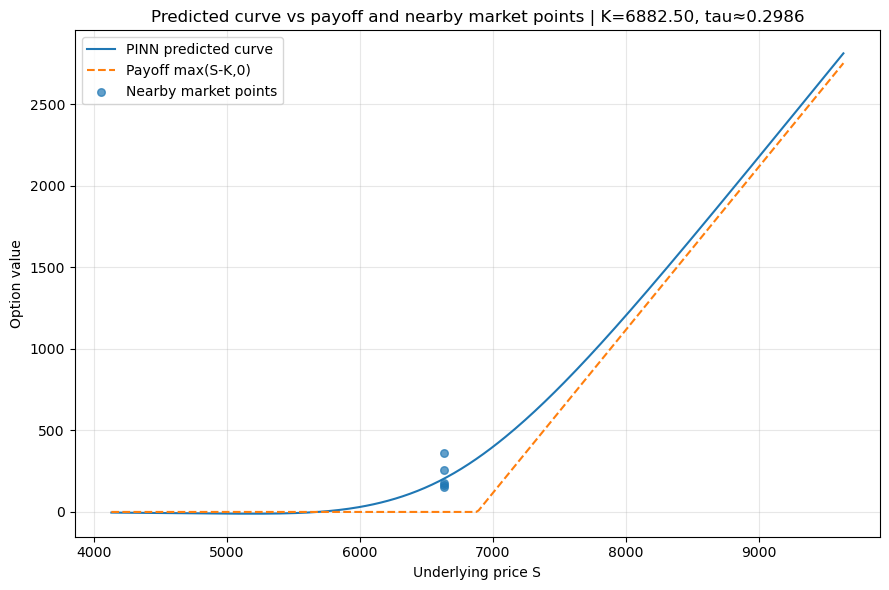

In [24]:
plot_curve_with_market_points(
    model=model,
    df=test_df,
    device=device,
    K=float(test_df["K"].median()),
    tau_target=float(test_df["tau"].median()),
    sigma_target=float(test_df["sigma"].median()),
    tau_tol=0.02,
    sigma_tol=0.05,
    price_col="V",
)

Scaled price MAE   : 0.000412
Scaled price RMSE  : 0.001389
Option price MAE   : 2.396725
Option price RMSE  : 5.949126


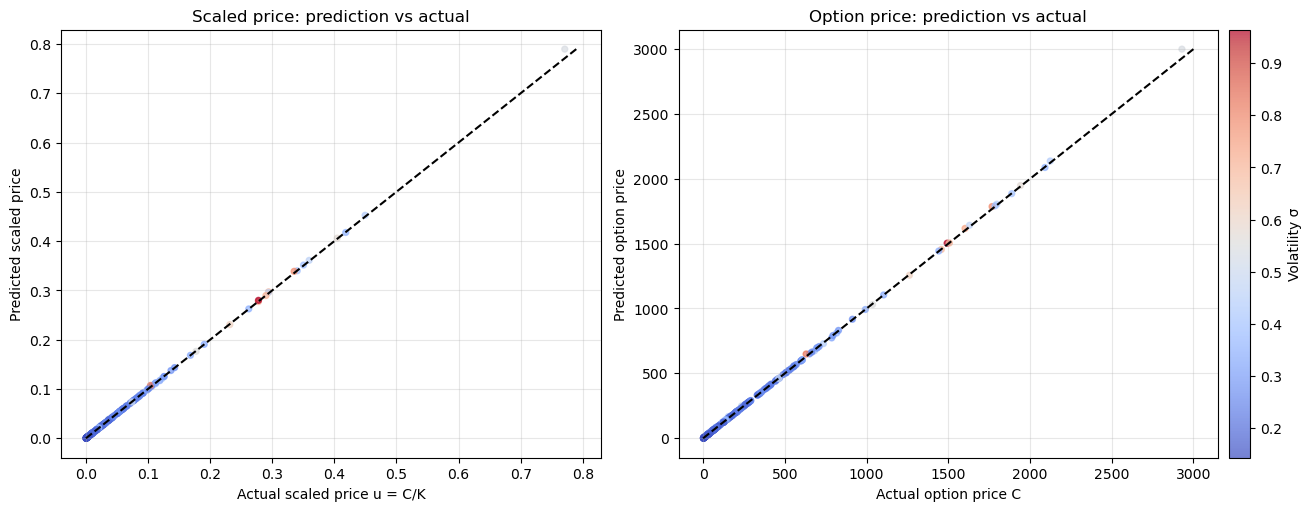

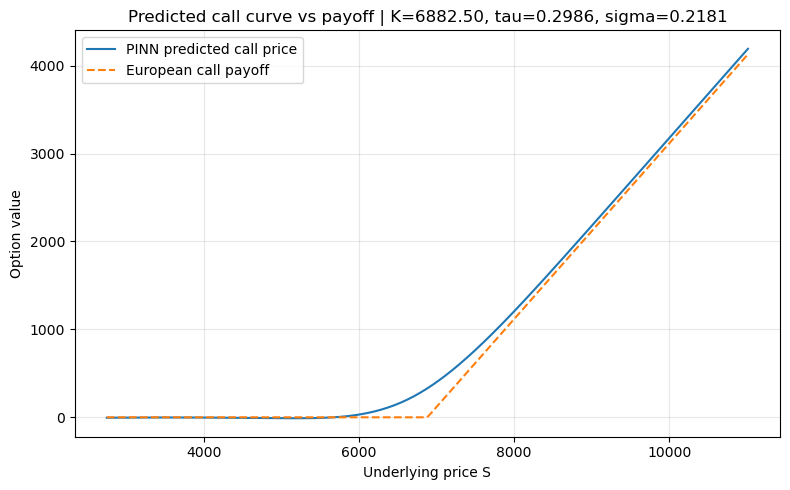

In [25]:
pred_df = make_prediction_df(model, test_df, device=device, price_col="V_scaled")
print_prediction_metrics(pred_df)
plot_prediction_scatter(pred_df)

plot_call_curve_vs_payoff(
    model=model,
    device=device,
    K=float(pred_df["K"].median()),
    tau=float(pred_df["tau"].median()),
    sigma=float(pred_df["sigma"].median()),
)

In [26]:
import torch

def black_scholes_price(S, K, tau, r, sigma, option_type="call"):
    """
    Black-Scholes price for European options, supporting scalars or torch tensors.

    Parameters
    ----------
    S : float or torch.Tensor
        Spot price
    K : float or torch.Tensor
        Strike price
    tau : float or torch.Tensor
        Time to maturity in years
    r : float or torch.Tensor
        Risk-free rate
    sigma : float or torch.Tensor
        Volatility
    option_type : str
        "call" or "put"

    Returns
    -------
    torch.Tensor
        Option price
    """
    S = torch.as_tensor(S)
    K = torch.as_tensor(K, dtype=S.dtype, device=S.device)
    tau = torch.as_tensor(tau, dtype=S.dtype, device=S.device)
    r = torch.as_tensor(r, dtype=S.dtype, device=S.device)
    sigma = torch.as_tensor(sigma, dtype=S.dtype, device=S.device)

    if option_type not in ("call", "put"):
        raise ValueError("option_type must be 'call' or 'put'")

    if torch.any(S <= 0):
        raise ValueError("All S values must be > 0")
    if torch.any(K <= 0):
        raise ValueError("All K values must be > 0")
    if torch.any(tau < 0):
        raise ValueError("All tau values must be >= 0")
    if torch.any(sigma < 0):
        raise ValueError("All sigma values must be >= 0")

    sqrt_tau = torch.sqrt(torch.clamp(tau, min=0))
    normal = torch.distributions.Normal(0.0, 1.0)

    # Safe values for divisions/logs; final output is overwritten where needed
    tau_safe = torch.clamp(tau, min=1e-16)
    sigma_safe = torch.clamp(sigma, min=1e-16)
    vol_sqrt_tau = sigma_safe * torch.sqrt(tau_safe)

    d1 = (torch.log(S / K) + (r + 0.5 * sigma_safe**2) * tau_safe) / vol_sqrt_tau
    d2 = d1 - vol_sqrt_tau

    call_price = S * normal.cdf(d1) - K * torch.exp(-r * tau_safe) * normal.cdf(d2)
    put_price = K * torch.exp(-r * tau_safe) * normal.cdf(-d2) - S * normal.cdf(-d1)

    price = call_price if option_type == "call" else put_price

    # Handle tau == 0
    intrinsic = torch.clamp(S - K, min=0.0) if option_type == "call" else torch.clamp(K - S, min=0.0)
    price = torch.where(tau == 0, intrinsic, price)

    # Handle sigma == 0 and tau > 0
    discounted_strike = K * torch.exp(-r * tau)
    zero_vol_price = (
        torch.clamp(S - discounted_strike, min=0.0)
        if option_type == "call"
        else torch.clamp(discounted_strike - S, min=0.0)
    )
    price = torch.where((sigma == 0) & (tau > 0), zero_vol_price, price)

    return price

In [27]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def build_surface_comparison(
    model,
    device,
    K,
    sigma,
    r,
    S_min=None,
    S_max=None,
    tau_min=1e-4,
    tau_max=1.0,
    n_S=120,
    n_tau=80,
):
    if S_min is None:
        S_min = 0.5 * K
    if S_max is None:
        S_max = 1.5 * K

    S_grid = np.linspace(S_min, S_max, n_S)
    tau_grid = np.linspace(tau_min, tau_max, n_tau)

    S_mesh, tau_mesh = np.meshgrid(S_grid, tau_grid)
    x_mesh = np.log(S_mesh / K)

    # Flatten for model evaluation
    x_flat = x_mesh.reshape(-1)
    tau_flat = tau_mesh.reshape(-1)
    sigma_flat = np.full_like(x_flat, sigma, dtype=np.float32)
    K_flat = np.full_like(x_flat, K, dtype=np.float32)
    S_flat = S_mesh.reshape(-1).astype(np.float32)

    # PINN prices
    C_pred = predict_price_from_inputs(
        model=model,
        logS_over_K=x_flat,
        tau=tau_flat,
        sigma=sigma_flat,
        K=K_flat,
        device=device,
    ).detach().cpu().numpy().reshape(n_tau, n_S)

    # Black-Scholes prices
    S_t = torch.tensor(S_flat, dtype=torch.float32, device=device).view(-1, 1)
    K_t = torch.tensor(K_flat, dtype=torch.float32, device=device).view(-1, 1)
    tau_t = torch.tensor(tau_flat, dtype=torch.float32, device=device).view(-1, 1)
    sigma_t = torch.tensor(sigma_flat, dtype=torch.float32, device=device).view(-1, 1)

    C_bs = black_scholes_price(
        S=S_t,
        K=K_t,
        tau=tau_t,
        r=r,
        sigma=sigma_t,
    ).detach().cpu().numpy().reshape(n_tau, n_S)

    abs_err = np.abs(C_pred - C_bs)

    return {
        "S_grid": S_grid,
        "tau_grid": tau_grid,
        "C_pred": C_pred,
        "C_bs": C_bs,
        "abs_err": abs_err,
    }

In [28]:
def plot_surface_heatmaps(surface_dict):
    S_grid = surface_dict["S_grid"]
    tau_grid = surface_dict["tau_grid"]
    C_pred = surface_dict["C_pred"]
    C_bs = surface_dict["C_bs"]
    abs_err = surface_dict["abs_err"]

    extent = [S_grid.min(), S_grid.max(), tau_grid.min(), tau_grid.max()]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].imshow(
        C_pred,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    axes[0].set_title("PINN predicted call price")
    axes[0].set_xlabel("Underlying price S")
    axes[0].set_ylabel("Time to maturity τ")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(
        C_bs,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    axes[1].set_title("Black-Scholes call price")
    axes[1].set_xlabel("Underlying price S")
    axes[1].set_ylabel("Time to maturity τ")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(
        abs_err,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    axes[2].set_title("Absolute error |PINN - BS|")
    axes[2].set_xlabel("Underlying price S")
    axes[2].set_ylabel("Time to maturity τ")
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

In [29]:
def plot_slices_over_S(surface_dict, taus_to_plot=(0.02, 0.10, 0.25, 0.50, 1.00)):
    S_grid = surface_dict["S_grid"]
    tau_grid = surface_dict["tau_grid"]
    C_pred = surface_dict["C_pred"]
    C_bs = surface_dict["C_bs"]

    plt.figure(figsize=(10, 6))

    for tau_target in taus_to_plot:
        idx = np.argmin(np.abs(tau_grid - tau_target))
        tau_used = tau_grid[idx]

        plt.plot(S_grid, C_pred[idx], label=f"PINN τ={tau_used:.3f}")
        plt.plot(S_grid, C_bs[idx], "--", label=f"BS τ={tau_used:.3f}")

    plt.xlabel("Underlying price S")
    plt.ylabel("Option value")
    plt.title("European call price vs underlying for several maturities")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [30]:
def plot_slices_over_tau(surface_dict, S_values_to_plot):
    S_grid = surface_dict["S_grid"]
    tau_grid = surface_dict["tau_grid"]
    C_pred = surface_dict["C_pred"]
    C_bs = surface_dict["C_bs"]

    plt.figure(figsize=(10, 6))

    for S_target in S_values_to_plot:
        idx = np.argmin(np.abs(S_grid - S_target))
        S_used = S_grid[idx]

        plt.plot(tau_grid, C_pred[:, idx], label=f"PINN S={S_used:.0f}")
        plt.plot(tau_grid, C_bs[:, idx], "--", label=f"BS S={S_used:.0f}")

    plt.xlabel("Time to maturity τ")
    plt.ylabel("Option value")
    plt.title("European call price vs maturity for several underlying levels")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [31]:
def run_bs_surface_demo(
    model,
    device,
    K,
    sigma,
    r,
    S_min=None,
    S_max=None,
    tau_min=1e-4,
    tau_max=1.0,
    n_S=120,
    n_tau=80,
):
    surface = build_surface_comparison(
        model=model,
        device=device,
        K=K,
        sigma=sigma,
        r=r,
        S_min=S_min,
        S_max=S_max,
        tau_min=tau_min,
        tau_max=tau_max,
        n_S=n_S,
        n_tau=n_tau,
    )

    plot_surface_heatmaps(surface)

    plot_slices_over_S(
        surface,
        taus_to_plot=(0.02, 0.10, 0.25, 0.50, 1.00),
    )

    S_vals = [
        0.8 * K,
        0.95 * K,
        1.0 * K,
        1.05 * K,
        1.2 * K,
    ]
    plot_slices_over_tau(surface, S_values_to_plot=S_vals)

    return surface

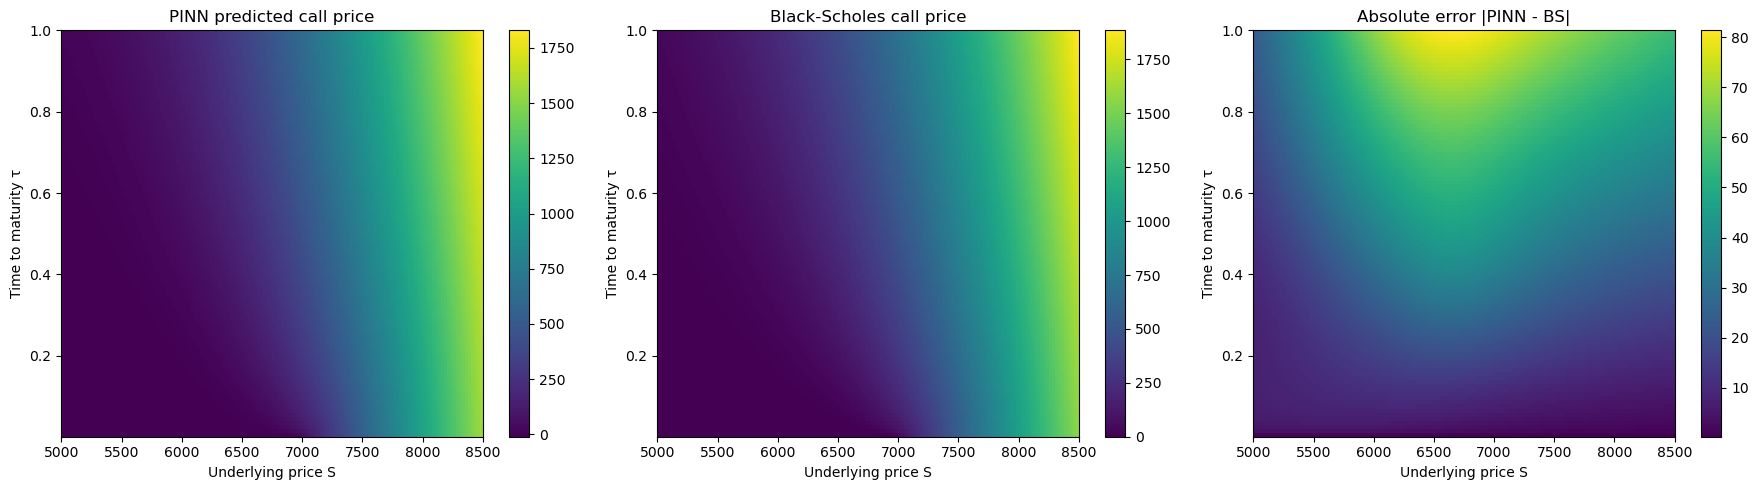

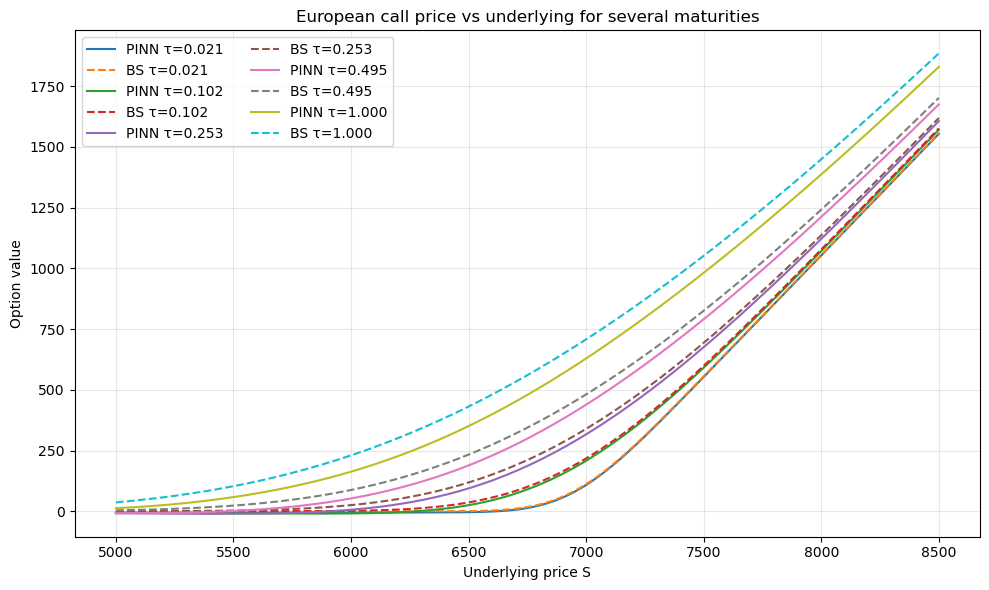

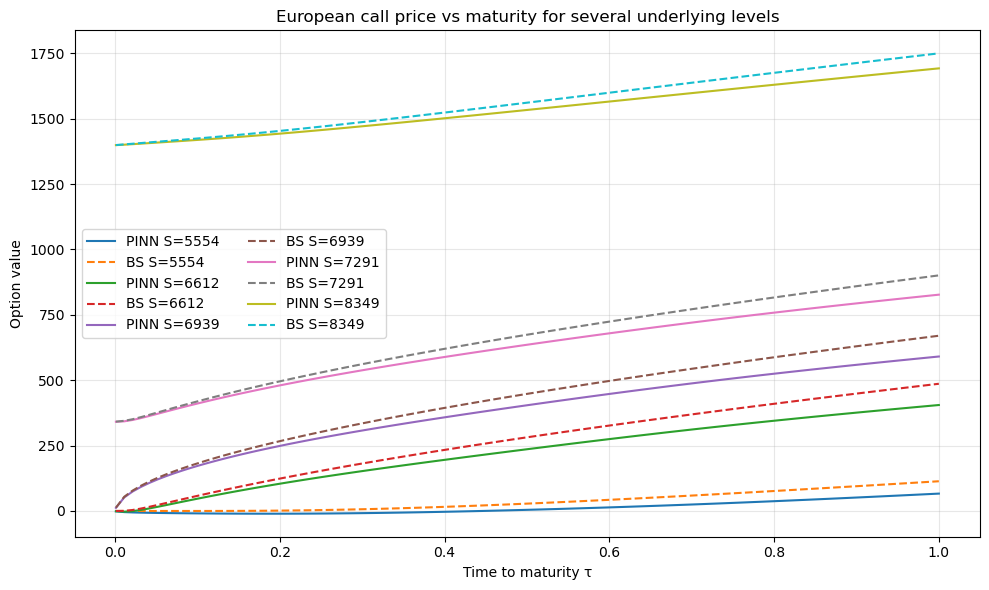

In [32]:
surface = run_bs_surface_demo(
    model=model,
    device=device,
    K=6950.0,
    sigma=0.2,
    r=r,
    S_min=5000,
    S_max=8500,
    tau_min=1e-3,
    tau_max=1.0,
    n_S=140,
    n_tau=100,
)